In [3]:
%matplotlib inline
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as snb

from scipy.optimize import minimize
from jax import value_and_grad
from jax import hessian
from jax import random

# for plotting
from matplotlib.colors import ListedColormap

# for manipulating images
from PIL import Image

from exercise7 import PCA_dim_reduction
from exercise7 import visualize_utility
from exercise7 import add_colorbar

from jax import config
config.update("jax_enable_x64", True)

# style stuff
snb.set_theme(font_scale=1.25)
snb.set_style('darkgrid')
colors = ['r', 'g', 'b', 'y']


# 02477 Bayesian Machine Learning - Exercise 7

**Overview**

The topic of this exercise is **multi-class classification** and **decision theory**. Probability theory and Bayes' rule tell us how to summarize our knowledge about a parameter or a prediction using probability distributions.  However, often we have to reduce these distributions a single decision, e.g. does the patient have cancer or not, and decision theory tells us how to do that in a principled manner. We will see how the **posterior predictive probabilities** play a key role in making **optimal decisions** and see how the choice of **utility function** affects the resulting decisions. We will also look at how to quantify and represent the predictive uncertainty for multi-class classification and how to investigate the reliability of the posterior predictive probabilities.

Studying **Bayesian linear models** for multi-class classification problems are important for many reasons: 1) a well-designed linear model can be hard to beat if data is not abundant and 2) linear models help us understand the theory and build intuition for more complex models. Finally, 3) the last layer of most deep neural networks for classification is equivalent to a linear model with a categorical likelihood. Hence, when we learn model parameters for the last layer only in a transfer learning setting, we actually fit a linear model for classification.

- Part 1: Bayesian linear models for multi-class classification
- Part 2: Bayesian decision theory for classification
- Part 3: Image classification
- Part 4: Making decisions with a reject option
- Part 5: Model calibration



Note that the in this exercise, we will need the python packages called **PIL** (for manipulating images) and **autograd** for computing derivatives. 


_____


## Part 1:  Bayesian linear models for multi-class classification

## Shapes Cheat‑Sheet

| Quantity                     | Symbol                   | Shape                  | Description                                                                 |
|-----------------------------|--------------------------|------------------------|-----------------------------------------------------------------------------|
| Input features              | $\mathbf{x}_n$         | $\mathbb{R}^M$       | Input vector for data point $n$                                           |
| Feature map                 | $\boldsymbol{\phi}(\mathbf{x}_n)$ | $\mathbb{R}^D$       | Transformed input features (may include bias term)                         |
| Weight matrix               | $\mathbf{W}$           | $\mathbb{R}^{K \times D}$ | Row $k$ corresponds to class weight vector $\mathbf{w}_k^\top$     |
| Scores (logits)            | $\mathbf{f}_n$         | $\mathbb{R}^K$       | Class scores for $\mathbf{x}_n$, computed as $\mathbf{W} \boldsymbol{\phi}(\mathbf{x}_n)$ |
| Class probabilities         | $\boldsymbol{\pi}_n$   | $\Delta^{K-1}$        | Softmax probabilities: $\boldsymbol{\pi}_n = \text{softmax}(\mathbf{f}_n)$ |
| One-hot target              | $\mathbf{y}_n$         | $\{0,1\}^K$           | One-hot encoded label with $\sum_k y_{nk} = 1$                            |
| Flattened weights (vector)  | $\text{vec}(\mathbf{W}) = \mathbf{w}_{\text{flat}}$ | $\mathbb{R}^{KD}$ | Vectorized version of $\mathbf{W}$ used in Laplace approximation         |



**From binary to multi-class classification**

In week 3, we discussed binary classification using logistic regression models. We used a *Bernoulli likelihood* with the *sigmoid inverse link function* to model the data, i.e. $$y_n \sim \text{Ber}(\sigma(f(\mathbf{x}_n)))$$ such that $$p(y=1|\mathbf{x}, \mathbf{w}) =  \sigma(f(\mathbf{x}_n)).$$ Due to the binary nature of $y_n$, we used that $$p(y=0|\mathbf{x}, \mathbf{w}) = 1 - p(y=1|\mathbf{x}, \mathbf{w}) = 1 - \sigma(f(\mathbf{x}_n)).$$ Because $y \in {0, 1}$, the single scalar score $f(x_n)$ fully determines both probabilities via the sigmoid inverse link.

This week we will work with the natural extension for multi-class classification. Consider a multi-class problem with $K$ classes and let $\mathcal{D} = \left\lbrace (\mathbf{x}_i, y_i) \right\rbrace_{i=1}^N$ denote a dataset, where $\mathbf{x}_i \in \mathbb{R}^M$ and $y_n \in \left\lbrace 1, 2, \dots, K\right\rbrace$ are the input feature and target label, respectively, for the $i$'th example. 

Since the targets are **discrete** and **unordered**, the categorical distribution with the softmax function is a standard choice:

> We introduce a K-dimensional latent vector of logits (or scores) $\mathbf{f}_n = f(\mathbf{x}_n) \in \mathbb{R}^K$, where $f(\cdot)$ is a linear function of the input features, i.e. $$\mathbf{f}_n = \mathbf{W} \boldsymbol{\phi}(\mathbf{x}_n),$$ where $\boldsymbol{\phi}(\cdot)$ is a feature map and $\mathbf{W} \in \mathbb{R}^{K \times D}$ is a weight matrix with $D$ being the dimensionality of the feature map. The latent vector $\mathbf{f}_n$ contains the scores for each class, and we can compute the class probabilities using the softmax function i.e (converting these logits into class probabilities with the **softmax** inverse link function):


$$\begin{align*}
y_n|\mathbf{f}_n &\sim \text{Categorical}\left[\text{softmax}(\mathbf{f}_n)\right], \tag{1} 
\end{align*}$$

where ${\mathbf{f}_n} \in \mathbb{R}^K$ is $K$-dimensional latent vector. In contrast to binary classification, $\mathbf{f}_n = f(\mathbf{x}_n) \in \mathbb{R}^K$ is now a $K$-dimensional vector. The output of the softmax-function is also a vector, where the elements are given by
$$\begin{align*}
\text{softmax}(\mathbf{f}_n)_i = \frac{\exp(\mathbf{f}_{n,i})}{\sum_{j=1}^K \exp( \mathbf{f}_{n,j})},
\end{align*}$$


where, for $i = 1, \ldots, K$, we have

$$
\pi_{n,i} := \operatorname{softmax}(\mathbf{f}_n)_i \quad = \quad p(y_n = i \mid \mathbf{x}_n, \mathbf{W}) \quad = \quad \frac{\exp(\mathbf{f}_{n,i})}{\sum_{j=1}^K \exp( \mathbf{f}_{n,j})}, \quad p(y_n = i \vert f_n) = \pi_{n,i} \tag{2}
$$



$\mathbf{f}_{n,i}$ denotes the $i$'th element of vector $\mathbf{f}_n$ and the probabilities of the categorical distribution is given by

$$\begin{align*}
\text{Categorical}(y_n = i|\mathbf{f}_n) = \text{softmax}(\mathbf{f}_n)_i.
\end{align*}$$


> **Why softmax?** We exponentiate logihs to make all sores positive and then normalize them to sum to one (all probabilities sum to 1). 
> A key property is **shift invariance**: if we add a constant to all logits, the probabilities remain unchanged. This is because the softmax function is invariant to shifts in the input, i.e. $\text{softmax}(\mathbf{f}_n + c) = \text{softmax}(\mathbf{f}_n)$ for any constant $c$. 


___________________________

**Linear models for multi-class classification**

Let $\{[x_n, y_n]\}_{n=1}^N$ be a dataset with $K$ classes. $\forall x_n \in \mathbb{R}^M$, (i.e. for each input), a feature map $\phi: \mathbb{R}^M \to \mathbb{R}^D$  produces $\phi(x_n) \in \mathbb{R}^D$. The model outputs a vector of class **scores** (or **logits**) $\mathbf{f}_n = f(\mathbf{x}_n) \in \mathbb{R}^K$, where $f(\cdot)$ is a linear function of the input features. The i-th entry of the vector $\mathbf{f}_n$ is given by $f_{n, i}$



For linear models for multi-class classification, we model each entry in $\mathbf{f}_{n}$ with a separate linear model, i.e.

$$\begin{align*}
\mathbf{f}_{n, i} &= f_i(\mathbf{x}_n) = \mathbf{w}_i^T \phi(\mathbf{x}_n) \quad\text{for}\quad i = 1, \dots, K, \tag{2} 
\end{align*}$$

where $\mathbf{w}_i \in \mathbb{R}^D$ and $\phi(\cdot)$ is a feature expansion such that $\phi(\mathbf{x}_n) \in \mathbb{R}^D$. 
Instead of $\mathbf{f}_{n, i} = \mathbf{w}_i^T \mathbf{x}_n $, we could also have used Gaussian processes or neural networks if desired.

Note that the linear models in eq. (2) is equivalent to

$$\begin{align*}
\mathbf{f}_n = \mathbf{W}\phi(\mathbf{x}_n),
\end{align*}$$

where $\mathbf{W} \in \mathbb{R}^{K \times D}$ and $\mathbf{w}_i \in \mathbb{R}^D$ is the $i$'th row of $\mathbf{W}$. This set-up is equivalent to the last layer of a neural network for multi-class classification.



> Multiclass Classification Model: Notation and Geometry

It is convenient to stack the class weight vectors as the rows of a parameter matrix 
$$
\mathbf{W} \in \mathbb{R}^{K \times D}, \quad \text{i.e.,} \quad 
\mathbf{W} = \begin{bmatrix}
\mathbf{w}_1^\top \\
\vdots \\
\mathbf{w}_K^\top
\end{bmatrix}.
$$

Then, the softmax input scores for data point $n$ can be written in vector form as:
$$
\underbrace{\mathbf{f}_n}_{K \times 1} = 
\underbrace{\mathbf{W}}_{K \times D} 
\underbrace{\boldsymbol{\phi}(\mathbf{x}_n)}_{D \times 1}
\quad \text{(or } \mathbf{f}_n = \mathbf{W} \boldsymbol{\phi}(\mathbf{x}_n) + \mathbf{b}, \, \mathbf{b} \in \mathbb{R}^K \text{)}.
$$

This is exactly the last linear layer of a neural network for multi-class classification. The feature map $\boldsymbol{\phi}(\cdot)$ may be the identity (purely linear model), a fixed basis expansion, or the output of preceding (possibly nonlinear) layers. The overall model remains linear in the features $\boldsymbol{\phi}(\mathbf{x})$.

To obtain class probabilities, we apply softmax to the scores:
$$
p(y_n = i \mid \mathbf{x}_n) 
= \frac{\exp(f_{n,i})}{\sum_{j=1}^K \exp(f_{n,j})}
= \left[\operatorname{softmax}(\mathbf{f}_n)\right]_i,
$$

and the usual prediction rule is:
$$
\hat{y}_n = \arg\max_i f_{n,i}.
$$

With softmax and cross-entropy loss, this forms the standard multinomial logistic regression (a generalization of binary logistic regression to $K$ classes).

> Geometry and Intuition

Each row $\mathbf{w}_i$ defines a direction in feature space. The score 
$$
f_{n,i} = \mathbf{w}_i^\top \boldsymbol{\phi}(\mathbf{x}_n)
$$ 
is the projection of $\boldsymbol{\phi}(\mathbf{x}_n)$ onto $\mathbf{w}_i$; a larger projection implies a higher preference for class $i$.

Class boundaries between class $i$ and $j$ occur where the two scores are equal:
$$
f_{n,i} = f_{n,j} 
\quad \Leftrightarrow \quad 
(\mathbf{w}_i - \mathbf{w}_j)^\top \boldsymbol{\phi}(\mathbf{x}) + (b_i - b_j) = 0,
$$

i.e., hyperplanes in the feature space. If $\boldsymbol{\phi}$ is nonlinear, these correspond to (potentially curved) boundaries in the original input space.

> Dataset-Level Matrix View 

Let 
$$
\boldsymbol{\Phi} = \begin{bmatrix}
\boldsymbol{\phi}(\mathbf{x}_1) & \cdots & \boldsymbol{\phi}(\mathbf{x}_N)
\end{bmatrix}
\in \mathbb{R}^{D \times N}, \quad
\mathbf{F} = \begin{bmatrix}
\mathbf{f}_1 & \cdots & \mathbf{f}_N
\end{bmatrix} \in \mathbb{R}^{K \times N}.
$$

Then we can write:
$$
\underbrace{\mathbf{F}}_{K \times N} = 
\underbrace{\mathbf{W}}_{K \times D} 
\underbrace{\boldsymbol{\Phi}}_{D \times N} +
\underbrace{\mathbf{b}}_{K \times 1} 
\underbrace{\mathbf{1}^\top}_{1 \times N},
$$

which clearly shows how the parameters $(\mathbf{W}, \mathbf{b})$ act on all $N$ samples at once, and highlights the shared feature map $\boldsymbol{\phi}$.

> Remark

Instead of the purely linear form 
$$
f_{n,i} = \mathbf{w}_i^\top \boldsymbol{\phi}(\mathbf{x}_n),
$$ 
one can replace $\boldsymbol{\phi}(\cdot)$ with features produced by a neural network or by other function classes (e.g., kernel features), while still using the same linear readout:
$$
\mathbf{f}_n = \mathbf{W} \boldsymbol{\phi}(\mathbf{x}_n) + \mathbf{b}.
$$

This preserves the interpretation above and the connection to a network’s final layer.

________________________________________


**The joint distribution**

To complete the Bayesian model, we impose a prior distribution for each $\mathbf{w}_i$, 

$$p(\mathbf{W}\vert \alpha) = \prod_{i=1}^K p(\mathbf{w}_i \vert \alpha) = \prod_{i=1}^K \mathcal{N}(\mathbf{w}_i|\mathbf{0}, \alpha^{-1}\mathbf{I}),$$

where $\alpha>0$ is a prior precision (larger $\alpha$ means more certain about the weights, stronger shrinage of weights towards zero). Putting these together and conditioning on the inputs $\mathbf{X} = (x_1, \ldots, x_N)$, the joint distribution factorizes as 

Specially, we impose zero-mean Gaussian prior on each $\mathbf{w}_i$ yielding the following joint distribution:

$$
\begin{align*}
p(\mathbf{y}, \mathbf{W} \vert \mathbf{X}, \alpha) = \prod_{n=1}^N p(y_n|\mathbf{W}, x_n) \prod_{i=1}^K p(\mathbf{w}_i \vert \alpha) = \prod_{n=1}^N \text{Cat}(y_n|\text{Softmax}(\mathbf{W}\phi(\mathbf{x}_n))) \prod_{i=1}^K \mathcal{N}(\mathbf{w}_i|\mathbf{0}, \alpha^{-1}\mathbf{I}_M).
\end{align*}
$$


---


### Generative Story (Bayesian Intuition)

We can interpret the model probabilistically as follows:

1. **For each class** $i$, draw weights from a Gaussian prior:

   $
   \mathbf{w}_i \sim \mathcal{N}\left( \mathbf{0}, \alpha^{-1} \mathbf{I}_D \right)
   $

2. **For each data point** $n$:

   - Compute scores:
     $
     \mathbf{s}_n = \mathbf{W} \, \boldsymbol{\phi}(\mathbf{x}_n)
     $

   - Compute class probabilities using softmax:
     $
     \boldsymbol{\pi}_n = \operatorname{softmax}(\mathbf{s}_n)
     $

   - Draw label:
     $
     y_n \sim \text{Categorical}(\boldsymbol{\pi}_n)
     $

---

This generative story makes explicit that:

- The labels $\{y_n\}$ are conditionally independent given $\mathbf{W}$.
- The Gaussian prior on $\mathbf{W}$ acts as a smoothness or complexity control.


_______



**Approximate inference using the Laplace approximation**

We will again resort to the Laplace approximation for inference because the posterior distribution is analytically intractable. The, 

$$
p(\mathbf{w}_{\text{flat}} \mid \mathbf{y}) 
\propto 
p(\mathbf{w}_{\text{flat}}) \prod_{n=1}^N p(y_n \mid \mathbf{W}, \mathbf{x}_n)
$$


is not availible in closed form: the softmax likeihood is **not conjugate** to a Gaussian prior and the normalizing integral couples all $KD$ parameters through the logits, making the marginalization intractable analytically.

We will therefore use **Monte Carlo** sampling to estimate the posterior predictive probabilities $p(y^* = k|\mathbf{y}, \mathbf{x}^*)$.

Compared to the Gaussian process set-up from last week, this implementation is fairly straight forward. However, to faciliate the implementation of the Laplace approximation, we will let $\mathbf{w}_{\text{flat}} = \begin{bmatrix} \mathbf{w}_1, \mathbf{w}_2, \dots, \mathbf{w}_K \end{bmatrix} \in \mathbb{R}^{K \cdot D}$ be a *flattened* version of $\mathbf{W} \in \mathbf{R}^{K\times D}$, where $K\cdot D$ is the total number of parameters of the model. We can then define the Laplace approximation to be

$$\begin{align*}
p(\mathbf{w}_{\text{flat}}|\mathbf{y}) \approx q(\mathbf{w}_{\text{flat}}) = \mathcal{N}(\mathbf{w}_{\text{flat}}|\mathbf{m}, \mathbf{S}), 
\end{align*}$$
where $\mathbf{m} \in \mathbb{R}^{K\cdot D}$ and $\mathbf{S} \in \mathbb{R}^{K\cdot D \times K \cdot D}$. From these quantities, we can extract the marginal posterior mean and covariance for each $\mathbf{w}_i$. For exampe, the approximate marginal posterior for $\mathbf{w}_1$ is $p(\mathbf{w}_1|\mathbf{y}) \approx \mathcal{N}(\mathbf{w}_1|\mathbf{m}_1, \mathbf{S}_1)$, where the mean $\mathbf{m}_1 \in \mathbb{R}^D$ for $\mathbf{w}_1$ is given by first $D$ entries in $\mathbf{m}$ and the marginal posterior covariance $\mathbf{S}_1 \in \mathbb{R}^{D \times D}$ is the first $D \times D$-entries in $\mathbf{S}$ and so on and so forth. But note that $\mathbf{S}$ also contains information about the posterior covariance between each pair of weight vectors $\mathbf{w}_i$ and $\mathbf{w}_j$.

In this exercise, we will rely on **JaX** for computing the gradient and Hessian.


<details>
<summary><strong> 🧠 Click to expand explanation of the flattened weights</strong></summary>

> Flattening the Weight Matrix

“Flattening” just means turning the $K \times D$ weight matrix into a single $KD$-dimensional vector in a fixed, agreed‑upon order—no values change, only their indexing does.

- Let $\mathbf{W} \in \mathbb{R}^{K \times D}$ with rows $\mathbf{w}_1^\top, \dots, \mathbf{w}_K^\top$, where each $\mathbf{w}_i \in \mathbb{R}^D$.

- We define the flattened vector:

  $$
  \mathbf{w}_{\text{flat}} = \operatorname{vec}(\mathbf{W}) = 
  \begin{bmatrix}
  \mathbf{w}_1 \\
  \mathbf{w}_2 \\
  \vdots \\
  \mathbf{w}_K
  \end{bmatrix} 
  \in \mathbb{R}^{KD},
  $$

  i.e., stack the class-specific weight vectors on top of each other (row-wise stacking).

- Equivalently, for indices $i \in \{1, \dots, K\}$ and $d \in \{1, \dots, D\}$:

  $$
  [\mathbf{w}_{\text{flat}}]_{(i-1)D + d} = \mathbf{W}_{i,d}
  $$

  > (Column-wise stacking is also valid — just be consistent.)

---

> Example

If $K = 2$, $D = 3$, and

$$
\mathbf{W} =
\begin{bmatrix}
a & b & c \\
d & e & f
\end{bmatrix},
$$

with 
$$
\mathbf{w}_1 = [a, b, c]^\top, \quad
\mathbf{w}_2 = [d, e, f]^\top,
$$

then:

$$
\mathbf{w}_{\text{flat}} = [a, b, c, d, e, f]^\top.
$$

---

> Why Flatten?

The Laplace approximation is a multivariate Gaussian over all parameters, which naturally lives in vector form:

$$
q(\mathbf{w}_{\text{flat}}) = \mathcal{N}(\mathbf{m}, \mathbf{S}), \quad \mathbf{m} \in \mathbb{R}^{KD}, \quad \mathbf{S} \in \mathbb{R}^{KD \times KD}.
$$

- Gradients are $\nabla_{\mathbf{w}_{\text{flat}}} \in \mathbb{R}^{KD}$.
- The Hessian is $KD \times KD$.
- Flattening allows us to use standard linear algebra operations.

---

> Reading Blocks Back

With row-wise stacking, the entries $[(i-1)D + 1 : iD]$ of $\mathbf{m}$ give the mean for class $i$.  
The corresponding $D \times D$ diagonal block of $\mathbf{S}$ gives the marginal covariance for $\mathbf{w}_i$.  
Off-diagonal $D \times D$ blocks give cross-class correlations.

---

> Prior Interpretation

An isotropic Gaussian prior:

$$
\mathcal{N}(\mathbf{0}, \lambda^{-1} \mathbf{I}_{KD})
$$

means each element of $\mathbf{W}$ is a priori independent with variance $\lambda^{-1}$.  
The specific stacking order does **not** change the prior — it only affects how you index or slice the vector.

---

> In Code

```python
w_flat = W.reshape(-1)        # Flatten row-wise
W = w_flat.reshape(K, D)      # Reshape back


<\details>
______________________________

_____

**Making predictions**

To predict the class of a new input $\mathbf{x}^*$, we marginalize over the posterior weights. To avoid a clash of symbols, let the covariance of $q$ be $\Sigma$, and use $J$ for the number of Monte‑Carlo samples.


To make predictions, we approximate the *posterior predictive distribution* using *Monte Carlo estimation*. 

$$\begin{align*}
p(y^* = k|\mathbf{y}, \mathbf{x}^*) \approx \int p(y^* =k| \mathbf{W}) q(\mathbf{W})\text{d}\mathbf{W} \approx \frac{1}{J} \sum_{j=1}^J p(y^* =k| \mathbf{W}^{(j)}) \quad\text{for}\quad \mathbf{W}^{(j)} \sim q(\mathbf{W})
\end{align*}$$

 for $j = 1, \dots, J$. To implement this, we simply draw the samples from $\mathbf{w}_{\text{flat}}^{(j)} \sim \mathcal{N}(\mathbf{w}_{\text{flat}}|\mathbf{m}, \mathbf{S})$ and then reshape each sample into $\mathbf{W}^{(j)} \in \mathbb{R}^{K\times D}$. Note that there also exists an extension of the probit approximation for multi-class classification.



> Sampling and Predictive Evaluation (Bayesian Multiclass Classification)

To make predictions from the variational posterior, we sample and evaluate as follows:


> 1. Draw Samples from the Posterior

Draw $J$ samples from the variational posterior over the **flattened parameter vector**, and reshape:

$$
\mathbf{w}_{\text{flat}}^{(j)} \sim \mathcal{N}(\mathbf{m}, \mathbf{\Sigma}), \qquad
\mathbf{W}^{(j)} = \text{reshape}(\mathbf{w}_{\text{flat}}^{(j)}) \in \mathbb{R}^{K \times D}
$$


> 2. For Each Sample $j = 1, \dots, J$:

- **Compute logits**:

  $$
  \mathbf{z}^{(j)} = \mathbf{W}^{(j)} \boldsymbol{\phi}(\mathbf{x}^*)
  $$

  *(Add a bias term if your model includes one.)*

- **Convert to class probabilities** using the softmax link function:

  $$
  p(y^* = k \mid \mathbf{x}^*, \mathbf{W}^{(j)}) 
  = \frac{\exp(z_k^{(j)})}{\sum_{\ell=1}^K \exp(z_\ell^{(j)})}
  $$


> 3. Average the Probabilities

Average the **probability vectors** (not the logits) across the $J$ samples:

$$
\hat{p}^k \equiv \frac{1}{J} \sum_{j=1}^J p_k^{(j)} 
\approx p(y^* = k \mid \mathbf{y}, \mathbf{x}^*), \qquad 
\hat{y}^* = \arg\max_k \hat{p}^k
$$


> 🤔 Intuition

Each $W^{(j)}$ is a **plausible classifier** under the posterior.  
We ask each one to “vote” on $x^*$ and average their **predicted class probabilities**.

Because the softmax is nonlinear:

$$
\operatorname{softmax}(\mathbb{E}[z]) \ne \mathbb{E}[\operatorname{softmax}(z)]
$$

→ **Averaging probabilities** is more correct than averaging logits, and leads to **better-calibrated predictions**.



> Optional: Quantify Predictive Uncertainty

You can measure the **dispersion across samples** for simple uncertainty summaries:

- **Variance of predicted probability for class $k$**:

  $$
  \widehat{\text{Var}}[p^k] = \frac{1}{J - 1} \sum_{j=1}^J \left(p_k^{(j)} - \hat{p}^k \right)^2
  $$

- **Predictive entropy**:

  $$
  H(\hat{\mathbf{p}}) = - \sum_{k=1}^K \hat{p}^k \log \hat{p}^k
  $$


> Note: Probit Link

If your **binary model** used a **probit link**, the multiclass analogue is the **multinomial probit**.

- The predictive integral still lacks a closed form
- The same Monte Carlo averaging applies
- Only the per-sample likelihood 
  $$
  p(y^* = k \mid \mathbf{x}^*, \mathbf{W}^{(j)})
  $$ 
  is changed to use the probit expression.



_______


**Note:** In the code we will represent the class labels as integers from $0, 1, \dots, K-1$ rather than from $1, \dots, K$ because Python counts from 0.

We will start with a small toy example with $K = 4$ classes.

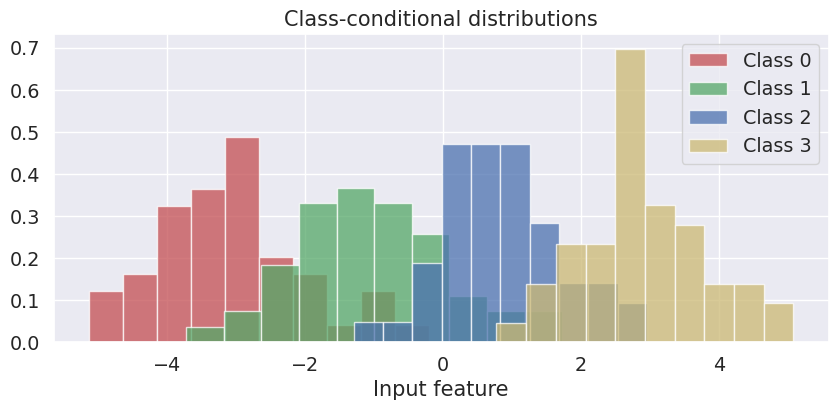

In [4]:
# seed
key = random.PRNGKey(123)
keys = random.split(key, 4)

# number of data points per class
M = 50

# generate simple synthetic toy dataset
xi = [-3 + random.normal(keys[0], shape=(M, 1)),
      -1 + random.normal(keys[1], shape=(M, 1)),
       1 + random.normal(keys[2], shape=(M, 1)),
       3 + random.normal(keys[3], shape=(M, 1))]
x = jnp.concatenate(xi)
y = jnp.hstack((jnp.zeros(M), jnp.ones(M), 2*jnp.ones(M), 3*jnp.ones(M)))
num_classes = 4

# specify input points for predictions
xstar = jnp.linspace(-6, 6, 300)

fig, ax = plt.subplots(1,1, figsize=(10, 4))
for i in range(4):
    ax.hist(xi[i], density=True, label='Class %d' % i, alpha=0.75, color=colors[i]);
ax.set(xlabel='Input feature', title='Class-conditional distributions')
ax.legend();


**Implementation**

**Task 1.1**: Complete the implementation of the `log_prior` and `log_likelihood` functions below.

*Hints:**
- *All the parameters of the model are i.i.d. as $\mathcal{N}(0, \alpha^{-1})$ under the prior distribution.*
- *The class variable `y_onehot` contains a onehot-representations of $\mathbf{y}$. Since we rely on JaX and autograd to compute the gradients and Hessian, you can only use `jax.numpy` functions in your implementation.* 

**Task 1.2**: Complete the implementation of `predict_y` below

*Hints:*
-  *Generate the desired number of samples from $\mathbf{w}^{(j)}_{\text{flat}} \sim \mathcal{N}(\mathbf{m}, \mathbf{S})$ and then reshape each sample to $K \times D$ weight matrix, e.g. $\mathbf{W}^{(j)} \in \mathbb{R}^{K \times D}$, and then perform the Monte Carlo estimation.*
- *If you want to check your implementation of the previous task before attempting this one, you can comment out the lines `phat = ...` and `axes[2].plot(xstar, phat...`. If you do so, you should see a plot of the posterior mean of the $K$ linear models.*

f_all_samples (4, 300, 500)
P_hat shape: (300, 4)


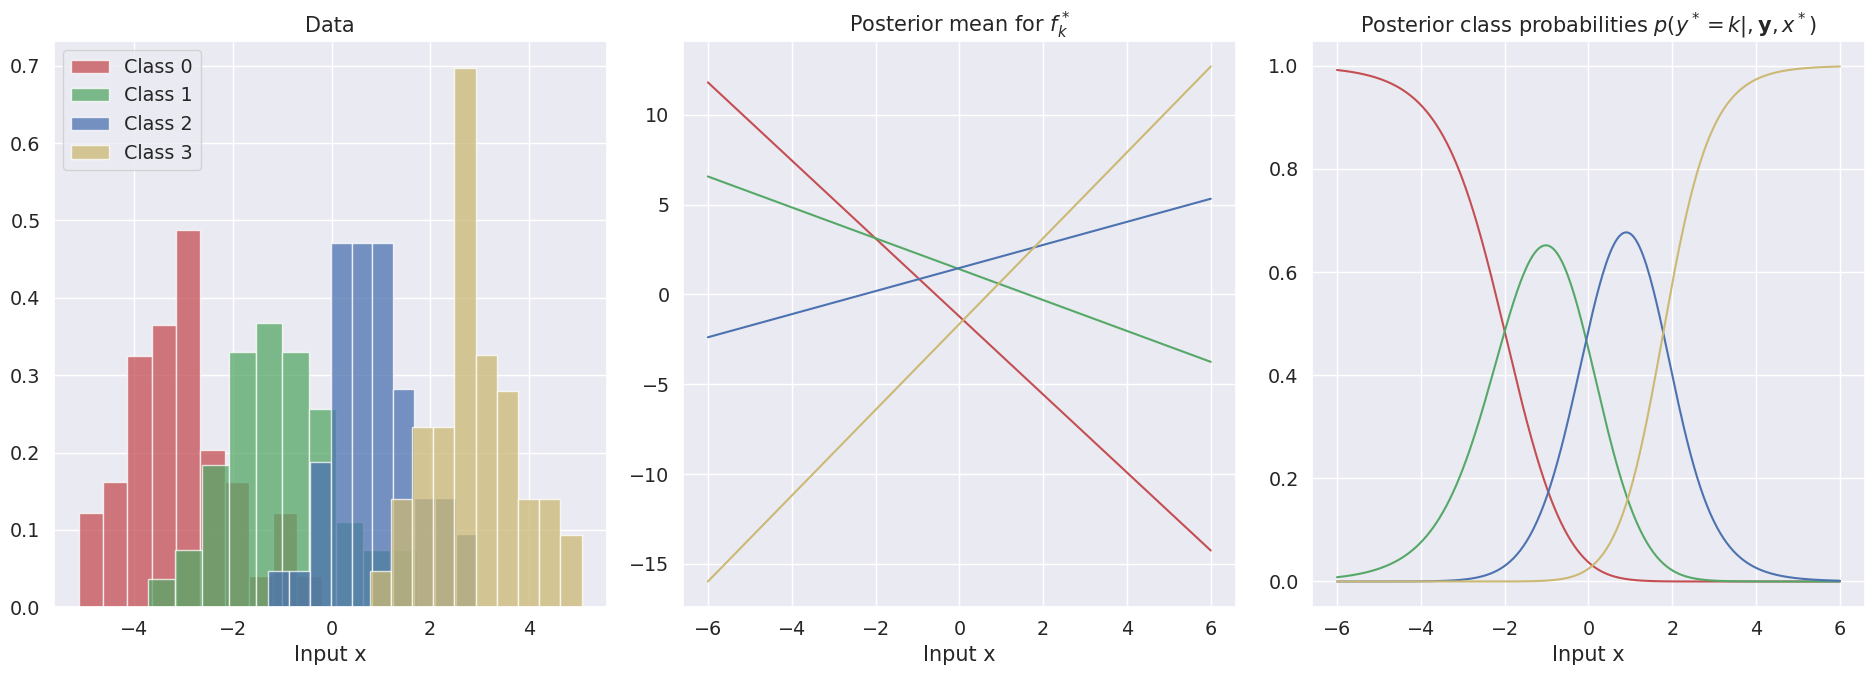

In [5]:
def log_npdf(x, m, v):
    return -0.5*(x-m)**2/v - 0.5*jnp.log(2*jnp.pi*v)

# convert from class label to one-hot encoding
def to_onehot(y, num_classes):
    return jnp.column_stack([1.0*(y==value) for value in jnp.arange(num_classes)])

# softmax transformation
def softmax(a):
    exp_a = jnp.exp(a)
    b = exp_a/jnp.sum(exp_a, 1)[:, None]
    return exp_a/jnp.sum(exp_a, 1)[:, None]



class BayesianLinearSoftmax(object):
    """ Bayesian linear softmax classifier with i.i.d. Gaussian priors """
    
    def __init__(self, X, y, alpha=1):
        
        # data and prior
        self.X, self.y  = X, y
        self.N, self.D = self.X.shape
        self.alpha = alpha
        
        # num classes, parameters and one-hot encoding
        self.num_classes = len(jnp.unique(y))
        self.num_params = self.num_classes * self.D
        self.y_onehot = to_onehot(self.y, self.num_classes)
        
        # fit
        self.compute_laplace_approximation()


    def log_prior(self, w_flat):
        """
        Evaluates the log prior of the model parameters, i.e., log p(W).

        Arguments:
        ----------
        w_flat : ndarray, shape = (T,)
            Flattened version of the weight matrix W, where T = num_classes * D.
            This is a single vector with all weights concatenated.

        Returns:
        --------
        log_prior_val : scalar
            The total log prior probability of the flattened weight vector.

        Assumes a standard Gaussian prior with zero mean and variance = 1 / alpha.
        That is, each entry in W is drawn independently from:
            N(0, 1/alpha)

        Therefore,
            log p(W) = sum over t of log N(w_flat[t] | 0, 1/alpha)
            
        
        Intuition: 
            w_flat is 1D array of all weights, shape = (K * D, )
            
            Each element is assume to be sampled from a normal distribution N(0, 1/alpha)
            
            log_npdf(w, 0, s) returns the log of the normal PDF:
                log N(w | 0, s^2) = -0.5 * log(2π) - log(s) - 0.5 * (w / s)^2
                
            jnp.sum(...) just add all these log-prob for each weight -> total log prior
            
        
        Example:
        --------
        >>> model = SoftmaxModel(X_train, y_train, alpha=1.0)
        >>> w_init = jnp.zeros(model.num_classes * model.D)
        >>> logprior = model.log_prior(w_init)
        >>> print("Log prior:", logprior)
        
        # Assume 4 weights and alpha = 1.0 -> std = 1.0 
        w_flat = jnp.array([0.0, 1.0, -1.0, 2.0])
        
        log_npdf(w_flat, 0, 1.0) =
        [-0.5*log(2π) - 0.5*(0)^2,
            -0.5*log(2π) - 0.5*(1)^2,
            -0.5*log(2π) - 0.5*(1)^2,
            -0.5*log(2π) - 0.5*(2)^2]
            ≈ [ -0.9189,
                -1.4189,
                -1.4189,
                -2.9189]

        log_prior_val = sum = -6.6756
        """
        # -------------------------------------------------------
        # !Compute sum of log probabilities under Normal(0, 1/alpha)
        # log_npdf returns elementwise log probability density values
        # log_prior_val is the total prior log-probability (scalar)
        # -------------------------------------------------------
        log_prior_val = jnp.sum(log_npdf(w_flat, 0, 1 / self.alpha))

        # -------------------------------------------------------
        # Safety check: ensure output is scalar
        # -------------------------------------------------------
        assert log_prior_val.shape == ()
        return log_prior_val
    
    
        
    def log_likelihood(self, w_flat):
        """ 
        Evaluates the log likelihood for dataset (self.X, self.y) using a Categorical distribution 
        with softmax inverse link function.

        Arguments:
        ----------
        w_flat : ndarray, shape = (T,)
            Flattened version of the weight matrix W, where T = num_classes * D. 
            This is a single vector that will be reshaped to W with shape (num_classes, D).
        
        Returns:
        --------
        loglik_val : scalar
            The total log likelihood of the dataset under the softmax classifier.
        
        Model:
        ------
        Let:
            - X be the input matrix of shape (N, D), where N is the number of data points and D is the number of features
            - W be the weight matrix of shape (K, D), where K is the number of classes
            - z_n = W @ x_n.T is the vector of logits (unnormalized scores) for data point n
            - softmax(z_n)[k] = exp(z_n[k]) / sum_j exp(z_n[j]) is the predicted probability for class k

        The categorical log-likelihood is given by:
            log p(y | X, W) = sum over n of sum over k of y_onehot[n, k] * log softmax(z_n)[k]
        where y_onehot is the one-hot encoded class label matrix of shape (N, K).

        Example:
        --------
        >>> model = SoftmaxModel(X_train, y_train)
        >>> w_init = jnp.zeros(model.num_classes * model.D)
        >>> loglik = model.log_likelihood(w_init)
        >>> print("Log likelihood:", loglik)
        
        # Suppose 3 data points and 3 classes
            p_all = jnp.array([
            [0.7, 0.2, 0.1],
            [0.1, 0.8, 0.1],
            [0.2, 0.3, 0.5]
            ])
        
        y_onehot = jnp.array([
            [1, 0, 0],   # true class is 0
            [0, 1, 0],   # true class is 1
            [0, 0, 1]    # true class is 2
            ])
            
        jnp.log(p_all) ≈ [
            [-0.357, -1.609, -2.303],
            [-2.303, -0.223, -2.303],
            [-1.609, -1.204, -0.693]
            ]

        y_onehot * jnp.log(p_all) ≈ [
            [-0.357, 0, 0],
            [0, -0.223, 0],
            [0, 0, -0.693]
        ]
        
        loglik_val = sum of correct log-probs = -0.357 -0.223 -0.693 = -1.273

        """
        # -------------------------------------------------------
        # !reshape from flat vector to matrix of shape (K, D)
        # where:
        #    K = number of classes
        #    D = number of features
        # -------------------------------------------------------        
        N = self.num_classes # num classes
        D = self.D           # num parmaeters
        W = w_flat.reshape((N, D))
        #print(f"Shape of W = {W.shape}")
            
        # -------------------------------------------------------
        # !Compute logits for each input:
        #   self.X: shape (N, D)
        #   W.T   : shape (K, D)
        # y_all = self.X @ W.T => (N, D) @ (K, D)^T = (N, D) @ (D, K)
        # => y_all: shape (N, K) — one row of logits per input
        # -------------------------------------------------------
        y_all = self.X @ W.T                                # shape (N, K)        

        # -------------------------------------------------------
        # !Normalize logits to probabilities using softmax
        #   softmax applied row-wise:
        #   p_all[n, k] = p(y_n = k | x_n)
        #   shape: (N, K)
        # -------------------------------------------------------
        p_all = softmax(y_all)
        
        # -------------------------------------------------------
        # !Compute log-likelihood:
        #   self.y_onehot: shape (N, K), binary 1 where true class
        #   jnp.log(p_all): shape (N, K)
        #   elementwise multiply picks only correct class log-prob
        #   sum over all datapoints gives scalar log-likelihood
        # -------------------------------------------------------
        loglik_val = jnp.sum(self.y_onehot * jnp.log(p_all))  # scalar


        # check dimensions and return
        assert loglik_val.shape == ()
        return loglik_val
            
    def log_joint(self, w_flat):
        """
        Computes the log of the joint distribution: log p(y, W) = log p(y | W) + log p(W)

        Arguments:
        ----------
        w_flat : ndarray, shape = (T,)
            Flattened version of the weight matrix W.

        Returns:
        --------
        log_joint_val : scalar
            The value of the joint log-probability for the given weights.

        Example:
        --------
        >>> model = SoftmaxModel(X_train, y_train)
        >>> w_init = jnp.zeros(model.num_classes * model.D)
        >>> joint = model.log_joint(w_init)
        >>> print("Log joint:", joint)

        # Suppose:
        #   log_prior_val = -6.6756
        #   log_likelihood_val = -1.273
        # Then:
        #   log_joint_val = log_prior_val + log_likelihood_val = -7.9486
        """
        # -------------------------------------------------------
        # !Evaluate total log joint = log prior + log likelihood
        # -------------------------------------------------------
        return self.log_prior(w_flat) + self.log_likelihood(w_flat)
        
    def compute_laplace_approximation(self):
        """
        Computes the Laplace approximation of the posterior distribution over weights.

        This method:
        1. Finds the MAP estimate of the weights by minimizing the negative log-joint
        2. Computes the Hessian of the negative log-joint at the MAP estimate
        3. Approximates the posterior as a Gaussian: N(w_MAP, H^{-1})

        Returns:
        --------
        m_flat : ndarray, shape = (T, 1)
            Mean vector of the approximate posterior (MAP weights)
        S_flat : ndarray, shape = (T, T)
            Covariance matrix (inverse Hessian at MAP)

        Example:
        --------
        >>> m, S = model.compute_laplace_approximation()
        >>> print("MAP weights:", m)
        >>> print("Covariance:", S)

        # Suppose:
        #   Negative log-joint has minimum at w_MAP = [0.5, -0.5]
        #   Hessian H = [[2, 0], [0, 4]]
        # Then:
        #   Covariance = inv(H) = [[0.5, 0], [0, 0.25]]
        """
        # -------------------------------------------------------
        # !Initialize weights with zeros
        # -------------------------------------------------------
        w_init_flat = jnp.zeros(self.num_params)

        # -------------------------------------------------------
        # !Define negative log-joint as cost function to minimize
        # -------------------------------------------------------
        cost_fun = lambda W: -self.log_joint(W)

        # -------------------------------------------------------
        # !Run optimization to find MAP estimate of weights
        # -------------------------------------------------------
        result = minimize(value_and_grad(cost_fun), w_init_flat, jac=True)

        if result.success:
            # -------------------------------------------------------
            # !MAP estimate of weights: shape (T,)
            # -------------------------------------------------------
            w_MAP = result.x
            self.m_flat = w_MAP[:, None]  # shape (T, 1)

            # -------------------------------------------------------
            # !Compute Hessian at MAP: shape (T, T)
            # -------------------------------------------------------
            self.A_flat = hessian(cost_fun)(w_MAP)

            # -------------------------------------------------------
            # !Compute posterior covariance (inverse Hessian)
            # -------------------------------------------------------
            self.S_flat = jnp.linalg.inv(self.A_flat)

            return self.m_flat, self.S_flat
        else:
            print('Warning optimization failed')
            return None, None
        
    def predict_f(self, X_star):
        """
        Computes the posterior  of latent functions f_i(x) = w_i^T x for all classes.
        distribution
        Arguments:
        ----------
        X_star : ndarray, shape = (P, D)
            Prediction points where P is the number of test inputs, and D is the number of features.

        Returns:
        --------
        mu_f_all_classes : ndarray, shape = (P, K)
            Predictive mean of latent function values for each class
        var_f_all_classes : ndarray, shape = (P, K)
            Predictive variance for each class across the P inputs

        Example:
        --------
        >>> mu_f, var_f = model.predict_f(X_test)
        >>> print("Posterior means:", mu_f)
        >>> print("Posterior variances:", var_f)

        # Suppose:
        #   m_k = [1, 2], S_k = [[0.1, 0], [0, 0.2]]
        #   X_star = [[1, 0], [0, 1]]
        # Then:
        #   mu_0 = X_star @ m_k.T = [1, 2]
        #   var_0 = diag(X_star @ S_k @ X_star.T) = [0.1, 0.2]
        """
        # -------------------------------------------------------
        # !Reshape flat posterior mean to (K, D)
        # -------------------------------------------------------
        m = self.m_flat.reshape((self.num_classes, self.D))

        # -------------------------------------------------------
        # !Extract diagonal blocks (D x D) from covariance matrix
        # One block per class
        # -------------------------------------------------------
        Si = [self.S_flat[i * self.D:(i + 1) * self.D, i * self.D:(i + 1) * self.D]
            for i in range(self.num_classes)]

        # -------------------------------------------------------
        # !Compute predictive mean for each class
        #   X_star: shape (P, D)
        #   m.T   : shape (D, K)
        #   Result: shape (P, K)
        # -------------------------------------------------------
        mu_f_all_classes = X_star @ m.T

        # -------------------------------------------------------
        # !Compute predictive variance for each class
        #   Result: shape (P, K), variance for each test point and class
        # -------------------------------------------------------
        var_f_all_classes = jnp.stack(
            [jnp.sum(X_star @ Si[i] * X_star, axis=1) for i in range(self.num_classes)], axis=1
        )

        return mu_f_all_classes, var_f_all_classes
        
    
    def predict_y(self, X_star, num_samples=500, seed=123):
        """
        Computes the posterior predictive distribution p(y^* = k | y, x^*) using Monte Carlo sampling.

        Arguments:
        ----------
        X_star : ndarray, shape = (P, D)
            Prediction points where P is the number of test inputs and D is the number of features
        num_samples : int
            Number of Monte Carlo samples to draw from the approximate posterior
        seed : int
            Random seed to ensure reproducibility

        Returns:
        --------
        p_all : ndarray, shape = (P, K)
            Posterior predictive probabilities for each point in X_star across K classes

        Example:
        --------
        >>> p_y = model.predict_y(X_test, num_samples=500)
        >>> print("Posterior predictive probabilities:", p_y)

        # Suppose:
        #   X_star = [[1, 0], [0, 1]]
        #   self.m_flat = [0.5, -0.5, 1.0, 0.0] (K=2, D=2)
        #   self.S_flat = identity matrix * 0.1
        # Then:
        #   W_samples ~ N(m_flat, S_flat)
        #   For each sample, compute logits X_star @ W.T, apply softmax
        #   Average over samples gives predictive class probabilities
        """

        key = random.PRNGKey(seed)

        # -------------------------------------------------------
        # !Sample weights from posterior: shape (num_samples, T)
        # where T = total number of parameters = K * D
        # -------------------------------------------------------
        w_samples_flat = random.multivariate_normal(
            key, self.m_flat.ravel(), self.S_flat, shape=(num_samples,)
        )  # shape (num_samples, K*D)

        # -------------------------------------------------------
        # !Reshape flat samples to (K, D, num_samples)
        # where:
        #   K = number of classes
        #   D = number of features
        #   num_samples = number of Monte Carlo draws
        # -------------------------------------------------------
        W_samples = w_samples_flat.T.reshape((self.num_classes, self.D, num_samples))

        # -------------------------------------------------------
        # !Compute latent function values f^* = X_star @ W for all samples
        #   X_star: shape (P, D)
        #   W_samples: shape (K, D, num_samples)
        #   Result: shape (K, P, num_samples)
        # -------------------------------------------------------
        f_all_samples = X_star @ W_samples  # shape (K, P, num_samples)
        print(f"f_all_samples {f_all_samples.shape}")

        # -------------------------------------------------------
        # !Reorder axes to (P, K, num_samples) for softmax and averaging
        # -------------------------------------------------------
        f_all_samples = jnp.swapaxes(f_all_samples, 0, 1)  # shape (P, K, num_samples)

        # -------------------------------------------------------
        # !Apply softmax to each sample: along axis=1 (classes)
        #   Result: shape (P, K, num_samples)
        # -------------------------------------------------------
        p_all_samples = softmax(f_all_samples)

        # -------------------------------------------------------
        # !Compute average predictive probability over samples
        #   Result: shape (P, K)
        # -------------------------------------------------------
        p_all = p_all_samples.mean(2)

        # Sanity check
        assert p_all.shape == (len(X_star), self.num_classes), (
            f"The shape of p_all was expected to be ({len(X_star)}, {self.num_classes}), "
            f"but the actual shape was {p_all.shape}. Please check the code"
        )
        return p_all


# linear model with intercept and slope
design_matrix = lambda x: jnp.column_stack((jnp.ones(len(x)), x))

# fit model and compute predictions
model = BayesianLinearSoftmax(design_matrix(x), y)
mu_f, var_f = model.predict_f(design_matrix(xstar))
phat = model.predict_y(design_matrix(xstar))

print(f"P_hat shape: {phat.shape}")

# plot
fig, axes = plt.subplots(1,3, figsize=(19, 7))
for i in range(4):
    # plot histogram of data
    axes[0].hist(xi[i], density=True, label='Class %d' % i, alpha=0.75, color=colors[i]);
    # plot posterior mean of latent function y for each class
    axes[1].plot(xstar, mu_f[:, i], label='i = %d' % i, color=colors[i])    
    # plot posterior class probabilitites
    axes[2].plot(xstar, phat[:, i], label='i = %d' % i, color=colors[i])
    
axes[0].legend()
for i in range(3):
    axes[i].set_xlabel('Input x')
    
axes[0].set_title('Data')
axes[1].set_title('Posterior mean for $f^*_k$')
axes[2].set_title('Posterior class probabilities $p(y^*=k|, \\mathbf{y}, x^*)$');

plt.tight_layout()
plt.savefig('probs.png', dpi=300, bbox_inches='tight')
plt.show()

**Task 1.3**: Study the plots above. Explain the role of the softmax-function in eq. (1) above and use the figures above to explain why the name "softmax" makes sense [**Discussion question**]


**Task 1.4**: Implement and plot the **confidence** and **entropy** for the predictive distributions above for each value of $x$ in the vector `xstar` (similar to the rightmost plot above). Comment on the relation between the confidence and entropy plots and the posterior predictive probabilities.



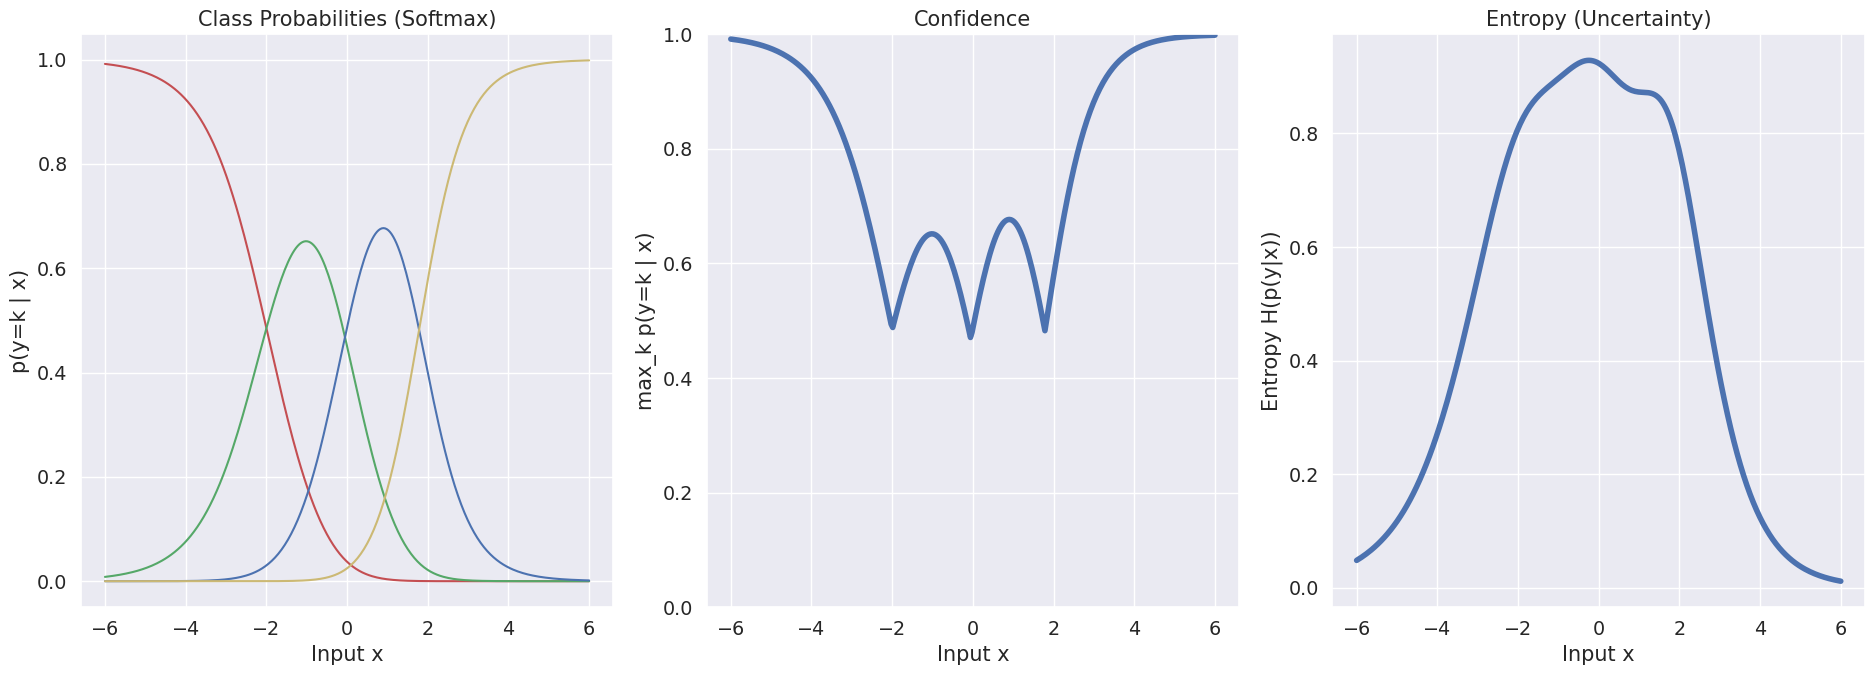

In [6]:
#print(jnp.argmax(phat, axis=1))


def confidence_teacher(p):
    """
    Computes the confidence score for each prediction point.

    The confidence is defined as the maximum predicted class probability
    for each input point. This reflects how confident the model is in its most likely class.

    Mathematically:
        confidence_n = max_k p[n, k]

    Args:
        p: jnp.ndarray of shape (N, K)
           - N: number of prediction points
           - K: number of classes
           - Each row must sum to 1 (i.e., valid softmax output)

    Returns:
        jnp.ndarray of shape (N,)
            - confidence[n] = max probability over classes for point n

    Example:
        >>> p = jnp.array([[0.1, 0.7, 0.2],
        ...                [0.3, 0.4, 0.3]])
        >>> confidence_teacher(p)
        Array([0.7, 0.4], dtype=float32)
    """
    return jnp.max(p, axis=1)


def confidence(phat):
    """
    Computes the confidence score by selecting the highest probability in each row
    using argmax and advanced indexing.

    This is equivalent to confidence_teacher, but explicitly demonstrates how to
    extract the value at the predicted class index.

    Mathematically:
        k_star[n] = argmax_k phat[n, k]
        confidence[n] = phat[n, k_star[n]]

    Args:
        phat: jnp.ndarray of shape (N, K)
              - Softmax probabilities for N prediction points across K classes

    Returns:
        jnp.ndarray of shape (N,)
            - Confidence scores: maximum predicted probability per row

    Example:
        >>> phat = jnp.array([[0.1, 0.7, 0.2],
        ...                   [0.3, 0.4, 0.3]])
        >>> confidence(phat)
        Array([0.7, 0.4], dtype=float32)
    """
    idx = jnp.argmax(phat, axis=1)              # shape (N,)
    row_indice = jnp.arange(phat.shape[0])      # shape (N,)
    vals = phat[row_indice, idx]                # shape (N,)
    return vals



def entropy(p):
    """
    Computes the entropy of the class probability distribution at each prediction point.

    Entropy is a measure of uncertainty:
    - High entropy → flat distribution → model is uncertain
    - Low entropy → peaked distribution → model is confident

    Mathematically:
        entropy_n = -Σ_k p[n, k] * log(p[n, k])

    Args:
        p: jnp.ndarray of shape (N, K)
           - Softmax probabilities per prediction point
           - Should sum to 1 across axis=1

    Returns:
        jnp.ndarray of shape (N,)
            - Entropy values for each prediction point

    Why `axis=1`?
        Because we sum over the **class probabilities** for each input point.

    Example:
        >>> p = jnp.array([[0.25, 0.25, 0.25, 0.25],
        ...                [0.97, 0.01, 0.01, 0.01]])
        >>> entropy(p)
        Array([1.3863, 0.1669], dtype=float32)  # Higher = more uncertain
    """
    return -jnp.sum(p * jnp.log(p), axis=1)





# Plot setup
fig, axes = plt.subplots(1, 3, figsize=(19, 7))

# Plot 1: Probabilities for each class across input points
for i in range(4):
    axes[0].plot(xstar, phat[:, i], label='i = %d' % i, color=colors[i])
axes[0].set_title("Class Probabilities (Softmax)")
axes[0].set_xlabel("Input x")
axes[0].set_ylabel("p(y=k | x)")

# Plot 2: Model confidence (highest predicted prob)
axes[1].plot(xstar, confidence(phat), linewidth=4)
axes[1].set_ylim(0, 1)
axes[1].set_title("Confidence")
axes[1].set_xlabel("Input x")
axes[1].set_ylabel("max_k p(y=k | x)")

# Plot 3: Entropy of predictive distribution
axes[2].plot(xstar, entropy(phat), linewidth=4)
axes[2].set_title("Entropy (Uncertainty)")
axes[2].set_xlabel("Input x")
axes[2].set_ylabel("Entropy H(p(y|x))")

plt.tight_layout()
plt.show()



## Part 2:  Bayesian decision theory for classification

Making a decision for multi-class classification entails assigning a class label $\hat{y}^* \in \left\lbrace 1, 2, \dots, K\right\rbrace$ to a new test point $\mathbf{x}^*$. In Bayesian decision theory, the utility function $\mathcal{U}(y^*, \hat{y})$ specifies the **utility** (i.e. gain) for predicting $\hat{y}^*$ when the true target is $y^*$.

In practice, we don't know the true target $y^*$, but the predictive posterior distribution $p(y^*|\mathbf{y}, \mathbf{x}^*)$ contains all the relevant knowledge about $y^*$ given our observed data $\mathbf{y}$. 
Let $$\pi_k := p(y^* = k|\mathbf{y}, \mathbf{x}^*), \quad k=1, \ldots, K,$$

so that $\pi_k=(\pi_1, \pi_2, \ldots, \pi_K)^T$ is the probability vector. The expeted utility of predicting class $\hat{y}$ is 

Therefore, we compute the **expected utility** wrt. the posterior predictive distribution for each possible value of $k$ is the posterior aveage of the utility function $\mathcal{U}$. 
\begin{align*}
EU(k) = \hat{y}^* = \arg\max\limits_{k \in \left\lbrace 1, 2, \dots, K\right\rbrace} \mathbb{E}_{p(y^*|\mathbf{y}, \mathbf{x}^*)}\left[\mathcal{U}(y^*, \hat{y}=k)\right] = \sum_{i=1}^K \mathcal{U}(i, k) \cdot \pi_i = \sum_{i=1}^K \mathcal{U}(i, k) \cdot p(y^* = i|\mathbf{y}, \mathbf{x}^*).
\end{align*}

Since $p(y^*|\mathbf{y}, \mathbf{x}^*)$ is a discrete probability distribution with probabilities $p(y^* = k|\mathbf{y}, \mathbf{x}^*) = \pi_k$, expectations with respect to $p(y^*|\mathbf{y}, \mathbf{x}^*)$ is simply a weighted sum.

We define the $K \times K$ utility matrix $\mathcal{U}$, by setting $\mathcal{U}(i, k) = u_{ik}$,("rows=true class, columns=predict class"). 

Then the vector of expected utilities over all actions is simply, 
$$(EU(1), EU(2), \ldots, EU(K))^T = \mathcal{U} \cdot \pi$$

The Bayes-optinal decision is then given by
$$\hat{y}^* = \arg\max_{k \in \left\lbrace 1, 2, \dots, K\right\rbrace} EU(k) = \arg\max_{k \in \left\lbrace 1, 2, \dots, K\right\rbrace} \sum_{i=1}^K \mathcal{U}(i, k) \cdot \pi_i = \arg\max_{k \in \left\lbrace 1, 2, \dots, K\right\rbrace} (U^T \cdot \pi)_k$$

## Recovering MAP Under 0/1-Utility

For the 0/1-utility (gain 1 for a correct label, 0 otherwise):

$$
U_{ik} =
\begin{cases}
1, & \text{if } i = k \\
0, & \text{if } i \neq k
\end{cases}
\quad \Rightarrow \quad \mathbb{E}[\mathcal{U}(k)] = \sum_{i=1}^K U_{ik} \, \pi_i = \pi_k
$$

Thus, the decision rule reduces to:

$$
\hat{y}^* = \arg\max_k \pi_k
$$

This is the **MAP (Maximum A Posteriori)** label.

### Intuition

With 0/1-utility, your expected gain for predicting class $k$ is exactly the probability that $k$ is correct. So you pick the most probable class.

---

## Equivalent Formulation Using Loss

Using the **0-1 loss** $\ell(y, \hat{y}) = \mathbb{I}[y \ne \hat{y}]$, the **posterior risk** is:

$$
R(k) = \mathbb{E}[\ell(y^*, k)] = 1 - \pi_k
$$

Minimizing risk is again equivalent to maximizing $\pi_k$, so the decision rule is the same.

---

## How Changing the Utility Changes the Decision

Utilities encode **what you value**. Changing $\mathcal{U}$ changes the decision boundaries.

---

### Class-Dependent Rewards

Suppose correct predictions yield different gains $w_k > 0$:
- $U_{kk} = w_k$
- $U_{ik} = 0 \quad \text{for } i \ne k$

Then:

$$
\mathbb{E}[\mathcal{U}(k)] = w_k \pi_k \quad \Rightarrow \quad \hat{y}^* = \arg\max_k w_k \pi_k
$$

**Worked example (K = 3):**

Let:  
$\pi = (0.40, 0.35, 0.25)$

- Under 0/1 utility: pick class 1 (since 0.40 is largest).
- If $w = (1, 1, 2)$ (class 3 is twice as valuable), then:

$$
\mathbb{E}[\mathcal{U}] = (0.40, 0.35, 0.50)
$$

So, pick **class 3**.

---

### Asymmetric Misclassification Costs (Binary Case)

With two classes and asymmetric losses:
- $c_{12}$ = cost of predicting 2 when truth is 1  
- $c_{21}$ = cost of predicting 1 when truth is 2  
Assume correct predictions cost 0.

Then the **posterior risks** are:

$$
R(1) = c_{21}(1 - \pi_1), \quad R(2) = c_{12} \pi_1
$$

Choose class 1 if:

$$
R(1) \le R(2) \quad \Rightarrow \quad \pi_1 \ge \frac{c_{12}}{c_{12} + c_{21}}
$$

So compared to the 0/1 threshold (0.5), a higher $c_{21}$ makes you more conservative about predicting class 1.

---

### Reject / Abstain Option

Add an action “**abstain**” with constant utility $u_0$ regardless of the true class:

$$
\mathbb{E}[\mathcal{U}(\text{abstain})] = u_0
$$

Under 0/1-utility:

- Predict a class only if $\max_k \pi_k \ge u_0$
- Otherwise, abstain.

This gives a simple **uncertainty threshold** on the posterior.

---

## Geometric Picture of Decision Regions

- Under 0/1-utility: decision boundaries occur where $\pi_i = \pi_j$.
- Under general utility: boundaries are where:

$$
\sum_r U_{ri} \pi_r = \sum_r U_{rj} \pi_r
$$

Increasing the reward $w_j$ (or decreasing penalties in column $j$) shifts boundaries outward, **enlarging the region** where class $j$ is optimal.

---

## Implementation Recipe

1. Compute the **posterior vector** $\pi$ for $\mathbf{x}^*$.
2. Form the **utility matrix** $\mathcal{U}$ (rows = true class, columns = predicted class).
3. Compute:

   $$
   \mathbf{e} = \mathcal{U}^\top \pi
   $$

4. Return:

   $$
   \hat{y}^* = \arg\max_k e_k
   $$

---

## Sanity Check

Applying a **positive affine transformation** $\mathcal{U}' = a\mathcal{U} + b$ (with $a > 0$ and constant $b$) does **not change** the decision rule:

$$
\arg\max_k \mathbb{E}[\mathcal{U}'(k)] = \arg\max_k (a \, \mathbb{E}[\mathcal{U}(k)] + b)
$$

---

## Practical Note

Expected utility decisions are **linear in $\pi$**, so **probability calibration matters**.

- Poor calibration leads to poor decisions—especially under asymmetric costs.
- Techniques like **temperature scaling**, **Platt scaling**, or **Dirichlet calibration** often help before decision-making.


In the videos we saw that in order to make optimal decisions under the **0/1-utility function** (remember utility is just negative loss and vice versa), we simply have to pick the class label with largest posterior probability. Let's investigate this empirically and study how the decision regions change when we change the utility-function.

**Task 2.1**: Complete the implementation of the function `compute_expected_utility`

*Hints: How do we compute expectations with respect to discrete distributions?*

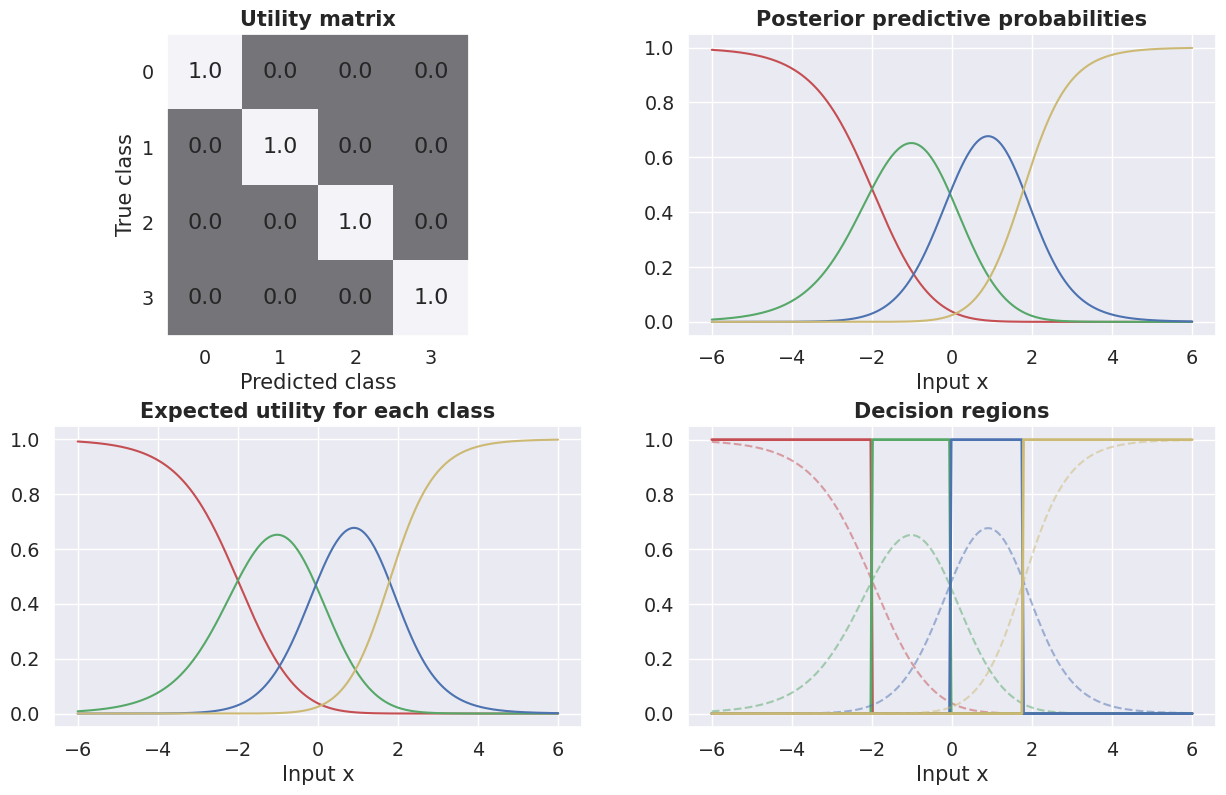

In [25]:
def compute_expected_utility(U, phat):
    """ computes the expected utility for a multi-class classification problem with K classes for utility matrix U and posterior predictive probabilities phat 
        
        Arguments
        U               --      Utility matrix (shape: [K x K])
        phat            --      Posterior predictive probabilities (shape: [P x K]), where P is the number of prediction points

        expected_util   --      Expected utility for each class for each point in phat (shape: P x K)           
           """
    

    expected_util = phat @ U

    # check dimensions and return
    assert expected_util.shape == phat.shape, f'The variable expected_util was expected to have shape {phat.shape}, but the actual shape was {expected_util.shape}. Please check your code.'
    return expected_util

# define utility matrix
U = jnp.identity(num_classes) 

#! TASK 2.4 Predict green, when the true class is green. That is U[0, 1] 



# compute the expected utility for each class
expected_utility = compute_expected_utility(U, phat) 

# make decisions
decisions = to_onehot(jnp.argmax(expected_utility, axis=1), num_classes)
    
# plot everything
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# utility matrix
visualize_utility(axes[0,0], U)

# posterior predictive probs
for i in range(num_classes):
    axes[0,1].plot(xstar, phat[:, i], color=colors[i])
axes[0,1].set_title('Posterior predictive probabilities', fontweight='bold')
axes[0,1].set_xlabel('Input x')

# expected utility
for i in range(num_classes):
    axes[1,0].plot(xstar, expected_utility[:, i], color=colors[i]);
axes[1,0].set_title('Expected utility for each class', fontweight='bold')
axes[1, 0].set_xlabel('Input x')

# decisions
for i in range(num_classes):
    axes[1,1].plot(xstar, decisions[:, i], color=colors[i], linewidth=2);
    axes[1,1].plot(xstar, phat[:, i], color=colors[i], alpha=0.5, linestyle='--')
axes[1,1].set_title('Decision regions', fontweight='bold')
axes[1,1].set_xlabel('Input x')

fig.subplots_adjust(hspace=0.3)
    

> **Task 2.2**: Use the figure above to explain how Bayesian decision theory works for multi-class classification. 

## 🔲 Top-left: Utility Matrix

Matrix $\mathcal{U}$ encodes the **gain (or loss)** for predicting class $\hat{y}$ when the true class is $y$. In this example, the utility matrix is:
- You get a gain of 1 for a correct prediction (on the diagonal), and 0 (off-diagonal) otherwise.

So the goal is to **maximize the probability of correct classification**. I.e. stadard 0-1 utility.

## 📈 Top-right: Posterior Predictive Probabilities
These are the class probabilities $\hat{p}(y=k | x)$ for each input $x$, estimated from your model. Each color curve represents one class. 

For a given input $x$, this panel tells us: 
- What is the **models belief** (probability) over each possile class. 

For example, around $x=0$, the blue class has the highest predicted probability. 

## 📊 Bottom-left: Expected Utility for Each Class
We compute the **expected utility** $\forall$ $k$ using the formula:
$$\mathbb{E}[\mathcal{U}(k)] = \sum_{j=1}^K p(y = j | x) \cdot U[j, k].$$

This is done for **each possible prediction $k$** so for each input $x$, you get one utility value per class. 

Because we uwed the utility matrix, this just becomes a weighted sum of the posterior probabilities, where the weights are given by the utility matrix.

$$\mathbb{E}[\mathcal{U}_k] = p(y=k | x)$$

#### EXAMPLE 

##### 🔧 Setup: Identity Utility Matrix (4 classes)

We have **4 classes** and an **identity utility matrix**:

$$
U = I_4 =
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
$$

Meaning:

- Utility = **1** if you correctly predict the class.
- Utility = **0** for any wrong prediction.

---

##### 🧮 Example: Single Prediction Point

Suppose at input point $x$, the model gives the following posterior predictive probabilities:

$$
\hat{p}(y|x) =
\begin{bmatrix}
0.1 \\
0.6 \\
0.2 \\
0.1
\end{bmatrix}
$$

---

##### ✅ Step-by-Step Expected Utility Calculation

For each possible **predicted class** $k$ (columns of $U$):

$$
E[U_k] = \sum_{j=0}^3 \hat{p}(y=j|x) \cdot U[j, k]
$$

This is just a **matrix multiplication**:

$$
\text{expected\_utility} = \hat{p}(y|x) \cdot U
$$

---

##### 🔢 Calculation

$$
\begin{aligned}
\text{expected\_utility} &=
\begin{bmatrix}
0.1 & 0.6 & 0.2 & 0.1
\end{bmatrix}
\cdot
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix} \\
&= \begin{bmatrix} 0.1 & 0.6 & 0.2 & 0.1 \end{bmatrix}
\end{aligned}
$$

---

##### 💡 Why is it identical to $\hat{p}(y|x)$?

- With the **identity matrix**, the utility of predicting class $k$ **only** depends on the probability that the true class is $k$.
- All **off-diagonal terms are zero**, so incorrect predictions don’t contribute to the utility.

Thus:

$$
E[U_k] = \hat{p}(y=k|x)
$$

---

##### 🔁 Generalization

- If you use a **non-identity utility matrix** (e.g., penalizing some misclassifications),  
  the expected utility becomes a **weighted combination** of all class probabilities.
- The **identity matrix** just acts as a selector — it directly picks out each class probability.

---
___
#### 🔁 Example: Non-Identity Utility Matrix

We keep the same **posterior predictive probabilities** as before:

$$
\hat{p}(y|x) =
\begin{bmatrix}
0.1 \\
0.6 \\
0.2 \\
0.1
\end{bmatrix}
$$

---

### 📋 Custom Utility Matrix

$$
U =
\begin{bmatrix}
1 & -2 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
$$

**Interpretation**:
- Mostly **identity**, except:
- **$U[0,1] = -2$** → Large penalty for predicting **class 1 (green)** when the **true class is 0 (red)**.

---

### 🧮 Expected Utility Calculation

For each predicted class $k$:

$$
E[U_k] = \sum_{j=0}^3 \hat{p}(y=j|x) \cdot U[j, k]
$$

---

### 🔢 Matrix Multiplication Form

$$
E[U] =
\begin{bmatrix}
0.1 & 0.6 & 0.2 & 0.1
\end{bmatrix}
\cdot
\begin{bmatrix}
1 & -2 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
$$

---

### 📊 Step-by-Step Computation

**Predicted class 0**:
$$
E[U_0] = 0.1 \cdot 1 + 0.6 \cdot 0 + 0.2 \cdot 0 + 0.1 \cdot 0 = 0.1
$$

**Predicted class 1**:
$$
E[U_1] = 0.1 \cdot (-2) + 0.6 \cdot 1 + 0.2 \cdot 0 + 0.1 \cdot 0
= -0.2 + 0.6 = 0.4
$$

**Predicted class 2**:
$$
E[U_2] = 0.1 \cdot 0 + 0.6 \cdot 0 + 0.2 \cdot 1 + 0.1 \cdot 0 = 0.2
$$

**Predicted class 3**:
$$
E[U_3] = 0.1 \cdot 0 + 0.6 \cdot 0 + 0.2 \cdot 0 + 0.1 \cdot 1 = 0.1
$$

---

### 📌 Final Result

| Predicted Class | Expected Utility |
|-----------------|------------------|
| 0               | 0.1              |
| 1               | **0.4 ✅**       |
| 2               | 0.2              |
| 3               | 0.1              |

---

### 🔄 Increasing the Penalty

If we **increase** the penalty to $U[0,1] = -4$:

**Predicted class 1**:
$$
E[U_1] = 0.1 \cdot (-4) + 0.6 \cdot 1 = -0.4 + 0.6 = 0.2
$$

Now, **class 2** ties with class 1 (both 0.2).  
If the penalty increases further, **class 1 will no longer be optimal**.

---

### 💡 Takeaway

Unlike **MAP classification** (which only picks the most probable class),  
**Bayesian Decision Theory** lets you **account for consequences** via the utility matrix:

- Discourage risky predictions (e.g., false positives in medical diagnosis).
- Favor caution or reward high-precision outcomes.
- Adapt decision boundaries according to the **costs and benefits** of each prediction.

____________________________

## 🚦 Bottom-right: Decision Regions

Here, we apply the **Bayesian decision rule:** 

> For each input $x$, predict the class $\hat{y}^*$ that give sthe highest expected utility:
$$ \hat{y}^* = \arg\max_k \mathbb{E}[\mathcal{U}(k)] = \arg\max_k \sum_{i=1}^K U_{ik} \cdot p(y=i|\mathbf{y}, \mathbf{x}^*).$$


- Solid vertical transitions show the decision boundaries.

- Dashed lines are again the class probabilities, for reference.

This shows how the decision boundaries depend directly on the expected utility values.

____
## ✅ Summary: How Bayesian Decision Theory Works

- Model prediction gives class probabilities $\hat{p}(y=k|\mathbf{x})$.

- You define a utility matrix $U$ that reflects your real-world rewards or costs.

- For each input $x$, compute the expected utility for predicting each class.

- Make the decision $\hat{y}^*$ that maximizes expected utility.

#### **With identity utility:**

- This reduces to maximum posterior probability (MAP classification).
$$ \hat{y}^* = \arg\max_k \hat{p}(y=k|\mathbf{x}) $$

#### **With custom utility:**

 You can bias decisions to favor or avoid certain classes, or encode asymmetric misclassification costs.

Let me know if you'd like an example with a non-identity utility matrix (e.g. penalizing false positives more heavily).

_________

> **Task 2.3**: What happens to the expected utilities and to the decisions if you scale the utility matrix by a positive constant? 


When I scale the utility matrix by a positive constant, 
$$ \mathcal{U}' = a \cdot \mathcal{U} + b, \quad a > 0, b \in \mathbb{R},
$$

the expected utilities change as follows:
$$\mathbb{E}[\mathcal{U}'(k)] = a \cdot \mathbb{E}[\mathcal{U}(k)] + b.$$
This means that the relative ordering of the expected utilities remains the same, as multiplying by a positive constant does not change the order of the values. The decision rule, which selects the class with the highest expected utility, remains unchanged.

> **Task 2.4**: What happens to the decision boundary if you introduce a negative utility of $-1$ for predicting 1 (green), when the true target is 0 (red)? What about $-2$? 

The green curve is pulled down where red probability is high, sometimes even going negative. That’s the penalty in action.

💡 Effect of penalty:

  The boundary between red (0) and green (1) shifts right.
- → The model now needs more evidence for green before it chooses it, to avoid the –1 penalty.

##### -1 

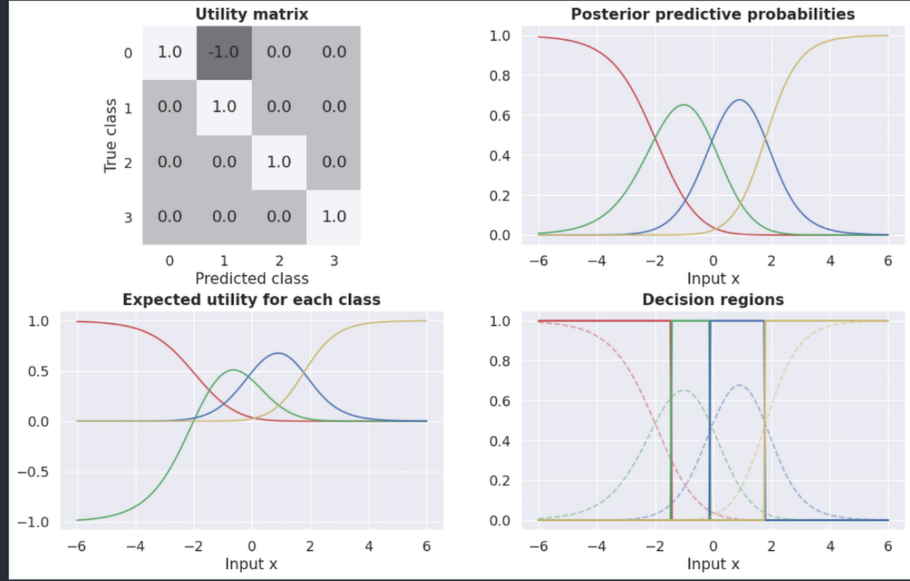
##### -2 
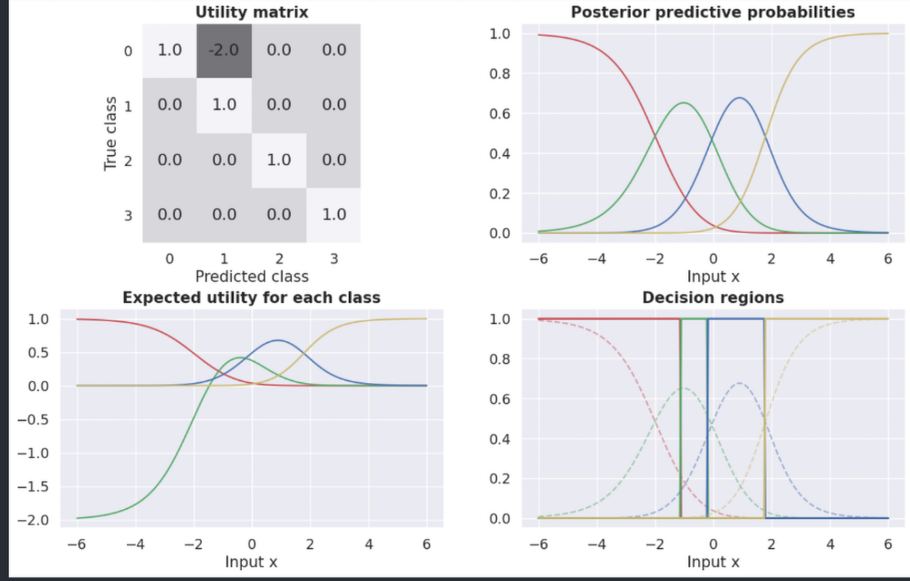

> **Task 2.5**: What happens if you change the 0/1 utility function to have $U_{23} = U_{32} = 1$? 


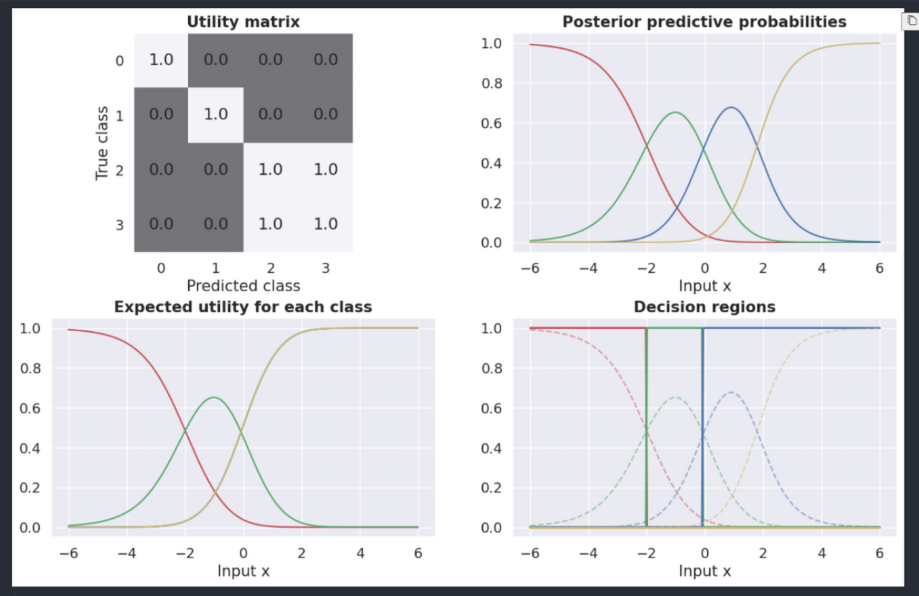

We have just made a class 2 (blue) and 3 (yellow) "equivalent". We have set the 0/1 to have $U_{23} = U_{32} = 1$, meaning that predicting class 2 when the true class is 3 (and vice versa) is now as good as a correct prediction. 

## 📐 Expected Utilities

Let:

$$
p_k(x) = p(y = k \mid x)
$$

Then the expected utility for predicting class $k$ is:

$$
E[U_k] = \sum_j p_j(x) \, U_{jk}
$$

---

### 🔢 With the modified utility matrix

1. **Class 0**:
$$
E[U_0] = p_0(x)
$$

2. **Class 1**:
$$
E[U_1] = p_1(x)
$$

3. **Class 2**:
$$
E[U_2] = p_2(x) \cdot 1 + p_3(x) \cdot 1 = p_2(x) + p_3(x)
$$

4. **Class 3**:
$$
E[U_3] = p_3(x) \cdot 1 + p_2(x) \cdot 1 = p_2(x) + p_3(x)
$$

Thus:

$$
E[U_2] = E[U_3] \quad \text{everywhere.}
$$

---

## 🗺 Decision Rule

Predict the class with the largest expected utility:

$$
\hat{y}(x) = \arg\max \big\{ \, p_0(x), \, p_1(x), \, p_2(x) + p_3(x), \, p_2(x) + p_3(x) \, \big\}
$$

---

## 📊 Decision Boundaries

- **Classes 2 and 3 behave as a single merged super-class**:

$$
S = \{ 2, 3 \}
$$

- **Boundary between class 0 and S**:
$$
p_0(x) = p_2(x) + p_3(x)
$$

- **Boundary between class 1 and S**:
$$
p_1(x) = p_2(x) + p_3(x)
$$

- **Boundary between class 0 and class 1** (unchanged from identity case):
$$
p_0(x) = p_1(x)
$$

- **No boundary between 2 and 3**:
  - They have identical expected utility everywhere.
  - In code, `argmax` will pick one deterministically (often class 2) unless a tie-breaker is added.

---

## 💡 Intuition

By making $U_{2,3} = U_{3,2} = 1$,  
you’ve told the classifier:

> “Predicting 2 counts as correct when the truth is 3, and vice versa.”

So the model only needs to decide between:
$$
\{ 0 \}, \quad \{ 1 \}, \quad \{ 2 \text{ or } 3 \}
$$


> **Task 2.6**: What happens if you change the 0/1 utility function to have $U_{11} = 0$? or to $U_{11} = 0.5$? 

## 📐 Setup

Let:

$$
p_k(x) = p(y = k \mid x)
$$

The **expected utility** for predicting class $k$ is:

$$
E[U_k] = \sum_j p_j(x) \, U_{jk}
$$

---

## 🎯 Utility Matrix Modification

We start from **0/1 utility** (identity matrix) and **only change** the diagonal entry for **class 1**:

$$
U_{11} = \alpha \quad \text{with} \quad \alpha \in \{0, \; 0.5\}
$$

All other entries unchanged:

- **Off-diagonals:** $0$
- **Other diagonals:** $1$

---

## 🧮 Expected Utilities

From the definition:

$$
E[U_0] = p_0(x)
$$
$$
E[U_1] = \alpha \, p_1(x)
$$
$$
E[U_2] = p_2(x)
$$
$$
E[U_3] = p_3(x)
$$

---

## 🗺 Decision Rule

We pick the class with the **largest expected utility**:

$$
\hat{y}(x) = \arg\max_k E[U_k]
$$

---

## 📊 Boundaries Against Class 1

For any other class $k \in \{0, 2, 3\}$, the boundary between class $1$ and class $k$ solves:

$$
\alpha \, p_1(x) = p_k(x)
\quad \iff \quad
\frac{p_1(x)}{p_k(x)} = \frac{1}{\alpha}
$$

---

### Special Cases

- **$\alpha = 1$ (original identity)**:
$$
p_1(x) = p_k(x)
$$


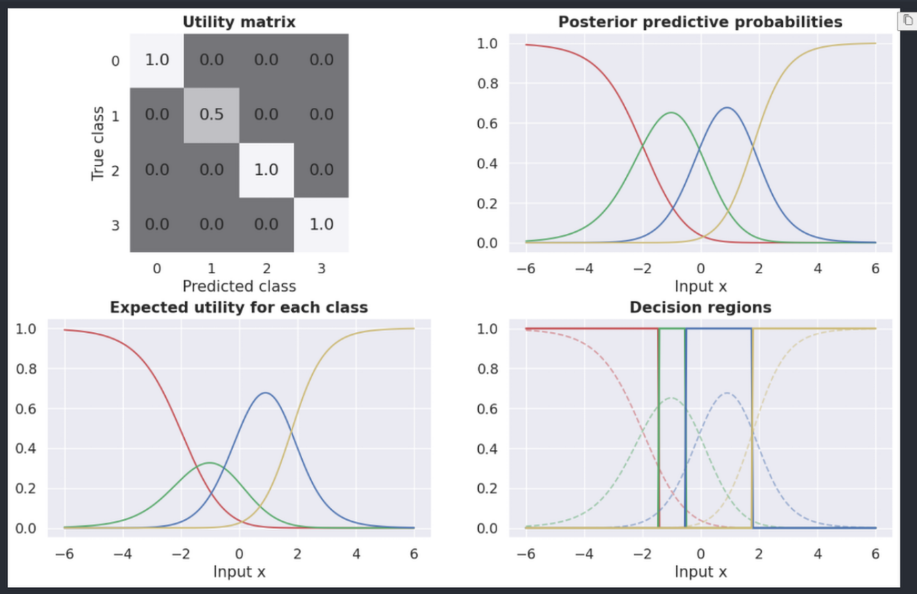

- **$\alpha = 0.5$**:
$$
p_1(x) = 2 \, p_k(x)
$$
Meaning: Class-1 region **shrinks** — you now need **twice as much** posterior mass on class 1 to choose it.

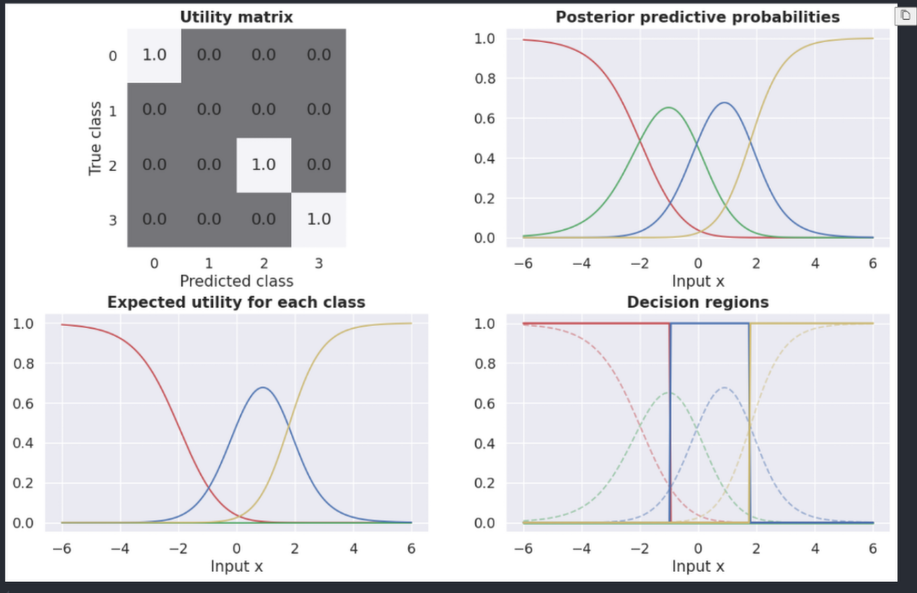

- **$\alpha = 0$**:
$$
E[U_1] = 0 \quad \text{everywhere}
$$
Class 1 is **never chosen** (unless all other expected utilities are also $0$, which doesn’t happen in practice).  
All of class 1’s former territory gets reassigned to whichever of $\{0, 2, 3\}$ has the largest $p_k(x)$.

---

## 💡 Intuition

Changing $U_{11}$ **scales class 1’s “score”** by $\alpha$:

- **$\alpha < 1$** → Penalizes being correct on class 1 → decision region **shrinks**; boundaries move **toward class 1**.
- **$\alpha = 0$** → Removes any reward for predicting 1 correctly → class 1 **disappears** from decisions.
- **$\alpha > 1$** → Expands class 1’s region; boundaries move **away** from class 1.

**Key point**: Just **rescale** $p_1(x)$ by $\alpha$ and compare to other $p_k(x)$ values.


## Part 3:  Image classification

It's now time to apply the material from part 1 and part 2 to a real dataset. Specifically, we will work with a subset of the Linnaeus 5 dataset (http://chaladze.com/l5/). The original Linnaeus 5 dataset contains images of size 256x256 from 5 classes, but we will work with a subset of this dataset containing a total of 3200 images in 4 classes (dogs, birds, flowers, berries). The images have been resized to 128x128 with the sole purpose of reducing the size of the data file. 

We will use **transfer learning** and use a pretrained ResNet18-network as a **feature extractor** for the images. ResNet18 is a convolutional neural network with 18 layers, which has been trained on a huge image dataset called ImageNet. The ImageNet containes images from 1000 different classes, which means that the very last layer of the ResNet architecture is a softmax-layer with 1000 outputs. However, if we get rid of the very last layer, we can use the rest of the network as a general feature extractor for images. That is, we propagate each image through the network we can use the very last hidden layer as a 512-dimensional feature vector for the image.

The details of how this works beyond what's written above is **not** part of the curriculum of the course and therefore, we have pre-computed feature vectors for all the images for you. 

However, if you are interested in the details, you can look at the following resources:

- Code used for feature extraction [here](https://github.com/christiansafka/img2vec)
- Paper describing the ResNet architecture [here](https://arxiv.org/pdf/1512.03385.pdf)
- A Pytorch tutorial for transfer learning for vision problems [here](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html#sphx-glr-beginner-transfer-learning-tutorial-py)


Let's load the data

In [26]:
data = jnp.load('./ex7_data.npz')
labels = list(data['labels'])
targets = data['targets']
num_classes = data['num_classes'][()]

img_train, img_test = data['Xtrain'], data['Xtest']
ytrain, ytest = data['ttrain'], data['ttest']
train_idx = data['train_idx']
test_idx = data['test_idx']

N, D = img_train.shape
Ntest = len(img_test)
print(f'Number of images for training: {N}')
print(f'Number of images for test: {Ntest}')
print(f'Number of features: {D}')
print(f'Number of clases: {num_classes}')


Number of images for training: 320
Number of images for test: 2880
Number of features: 512
Number of clases: 4


.. and plot a few examples

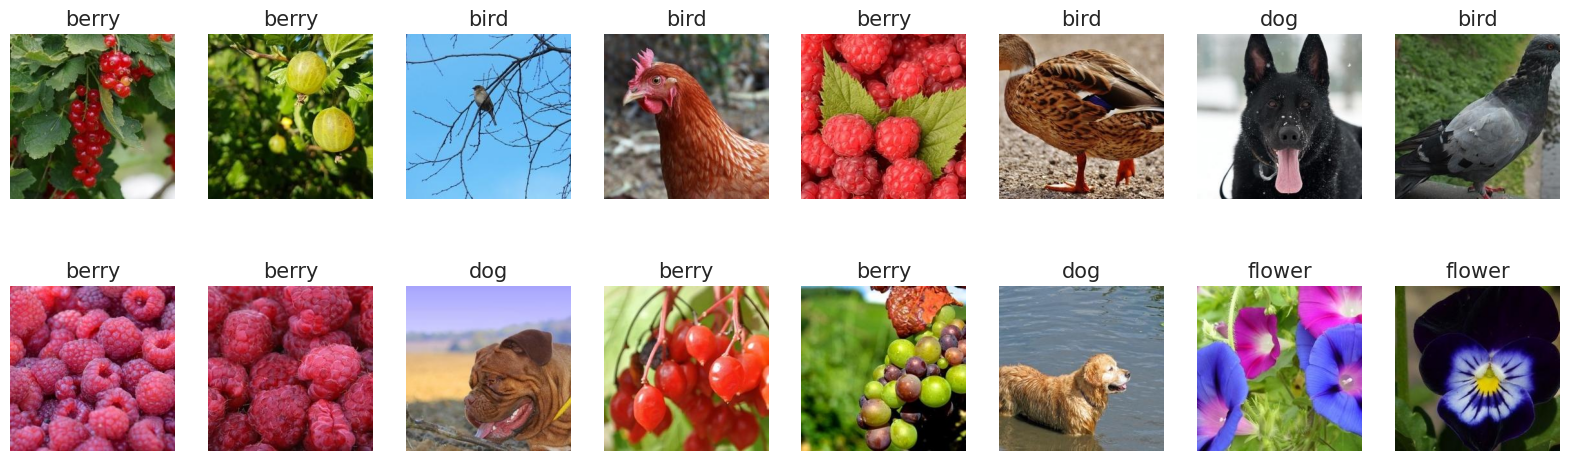

In [27]:
def show_example(ax, i):
    """ show training example i """
    
    j = train_idx[i]
    img = Image.open('./images/%d.jpg' % j)
    target = targets[j]
    ax.imshow(img)
    ax.set_title(labels[int(target)])
    ax.grid(False)
    ax.axis('off')

fig, ax = plt.subplots(2, 8, figsize=(20, 6))
for i in range(16):
    show_example(ax.flat[i], i)

Each image is represented using a 512-dimensional feature vector, but we will (again) reduce the dimensionality to $D = 2$ using principal component analysis (PCA) for the purpose of visualization.

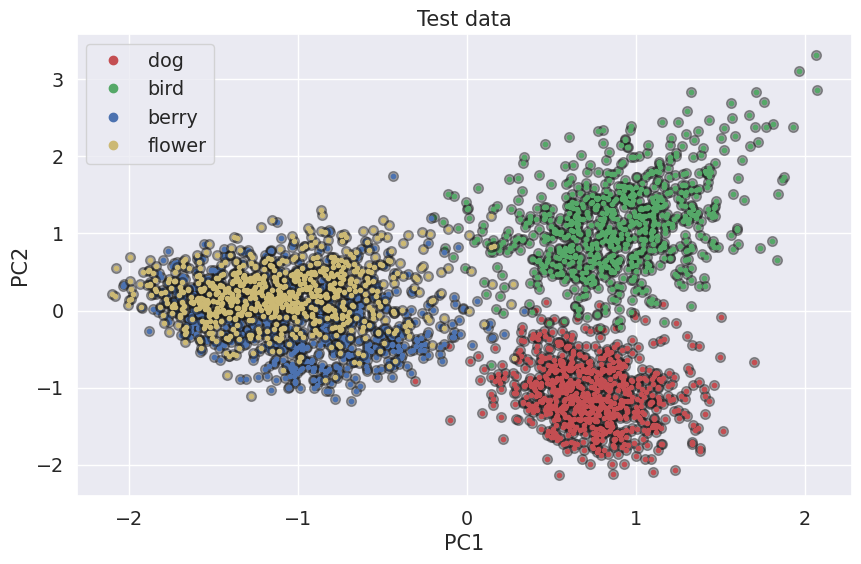

In [28]:
Ztrain, Ztest = PCA_dim_reduction(img_train, img_test, num_components=2)

def plot_pca_data(ax, legend=True, alpha=1):

    for i in range(num_classes):
        ax.plot(Ztest[ytest==i, 0], Ztest[ytest==i, 1], '.', color='k', markersize=14, alpha=0.4)
        ax.plot(Ztest[ytest==i, 0], Ztest[ytest==i, 1], '.', color=colors[i], label=labels[i], markersize=6, alpha=alpha)
    if legend:
        ax.legend(markerscale=2)
    ax.set(xlabel='PC1', ylabel='PC2')
    ax.set_title('Test data')

fig, ax = plt.subplots(figsize=(10, 6))
plot_pca_data(ax);


Let's  fit the model and visualize the posterior class probabilitites.

f_all_samples (4, 10000, 500)


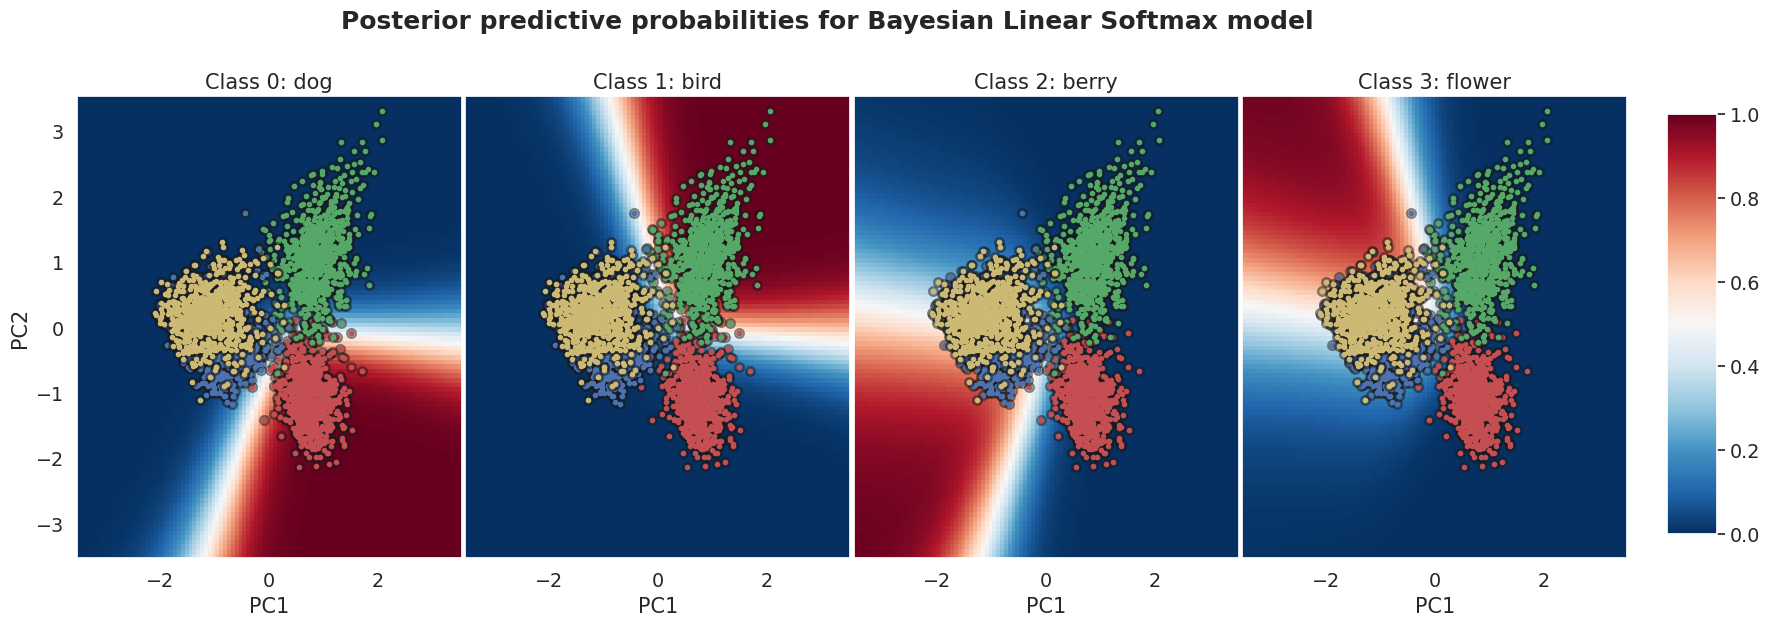

In [29]:
def visualize_regions(x_grid, posterior_class_probs, name, show_data=True):
    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 6))
    for i in range(num_classes):
        
        probs_reshaped =  posterior_class_probs[:, i].reshape((len(x_grid), len(x_grid)))
        im = axes[i].pcolormesh(x_grid, x_grid,probs_reshaped, cmap=plt.cm.RdBu_r, clim=(0, 1), shading='auto')

        if show_data:
            plot_pca_data(axes[i], legend=False)
        axes[i].set_title('Class %d: %s' % (i, labels[i]))

        if i > 0:
            axes[i].set_yticklabels([])
            axes[i].set_ylabel('')

    fig.subplots_adjust(right=0.9, wspace=0.01)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.025, 0.7])
    fig.colorbar(im, cax=cbar_ax);
    fig.suptitle(name, fontweight='bold', y=1.025)
        
# we want to have an intercept in the model
X_train, X_test = design_matrix(Ztrain), design_matrix(Ztest)
 
# prepare grid for making predictions
x_grid = jnp.linspace(-3.5, 3.5, 100)
XX1, XX2 = jnp.meshgrid(x_grid, x_grid)
Xp = jnp.column_stack((XX1.ravel(), XX2.ravel()))
X_pred = design_matrix(Xp)

# Fit linear classifier
model = BayesianLinearSoftmax(X_train, ytrain)
p_pred = model.predict_y(X_pred)

# visualize the posterior class proabilities for each model
visualize_regions(x_grid, p_pred, 'Posterior predictive probabilities for Bayesian Linear Softmax model')

**Task 3.1**: Compute predictions (wrt. the 0/1-utility function) and compute the accuracy for the training and test set.

def compute_acciracy(y_true, y_pred):
    return np.mean(y_true.ravel() == y_pred.ravel())


In [30]:
def compute_accuracy(y_true, y_pred):
    return jnp.mean(y_true.ravel() == y_pred.ravel())


# find class probabilites for training and test set usint he Bayesian linear softmax 

p_train = model.predict_y(X_train)
p_test = model.predict_y(X_test)

# classify using the 0/1 utility function 
ytrain_hat = jnp.argmax(p_train, axis=1)
ytest_hat = jnp.argmax(p_test, axis=1)

# using the 0/1 utility function, compute the accuracy on training and test set
# compute the expected utility for each class
expected_utility_train = compute_expected_utility(U, p_train) 
expected_utility_test = compute_expected_utility(U, p_test)

# make decisions
decisions_train = to_onehot(jnp.argmax(expected_utility_train, axis=1), num_classes)
decisions_test = to_onehot(jnp.argmax(expected_utility_test, axis=1), num_classes)


# compute accuracy
acc_train = compute_accuracy(ytrain, ytrain_hat)
acc_test = compute_accuracy(ytest, ytest_hat)
print(f'Accuracy on training set: {acc_train:.2f}')
print(f'Accuracy on test set: {acc_test:.2f}')

# do the same for the decisions train and test 

acc_train_decisions = compute_accuracy(ytrain, jnp.argmax(decisions_train, axis=1))
acc_test_decisions = compute_accuracy(ytest, jnp.argmax(decisions_test, axis=1))
print(f'Accuracy on training set (decisions): {acc_train_decisions:.2f}')
print(f'Accuracy on test set (decisions): {acc_test_decisions:.2f}')

f_all_samples (4, 320, 500)
f_all_samples (4, 2880, 500)
Accuracy on training set: 0.85
Accuracy on test set: 0.80
Accuracy on training set (decisions): 0.85
Accuracy on test set (decisions): 0.80


**Task 3.2**: Compute and plot the **entropy** and **confidence** for the predictions in the plot above. In which areas of the input space is this model most uncertain about the class label?

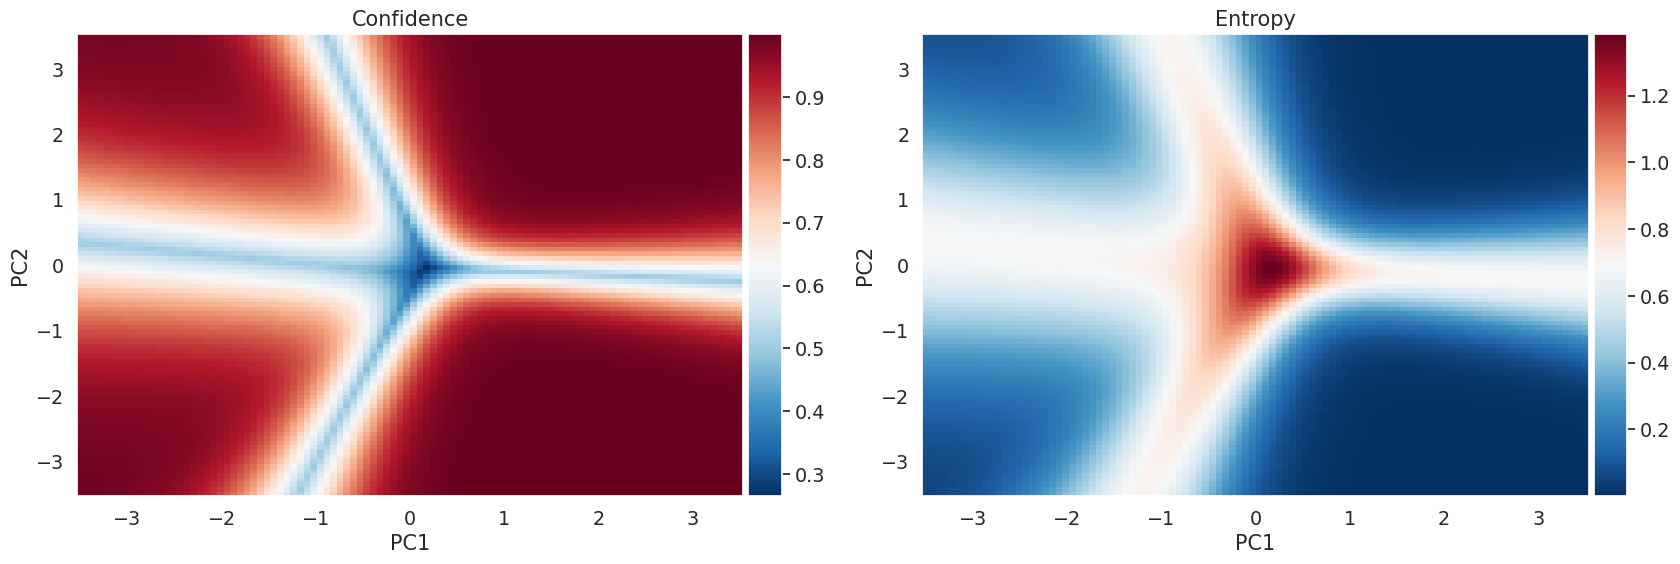

In [38]:

fig, ax = plt.subplots(1, 2, figsize=(20, 6))
im0 = ax[0].pcolormesh(x_grid, x_grid, confidence(p_pred).reshape((len(x_grid), len(x_grid))), shading='auto', cmap=plt.cm.RdBu_r)
im1 = ax[1].pcolormesh(x_grid, x_grid, entropy(p_pred).reshape((len(x_grid), len(x_grid))), shading='auto', cmap=plt.cm.RdBu_r)
ax[0].set(xlabel='PC1', ylabel='PC2', title='Confidence')
ax[1].set(xlabel='PC1', ylabel='PC2', title='Entropy');
add_colorbar(im0, fig, ax[0])
add_colorbar(im1, fig, ax[1])

#### 1) Confidence 

Defined as maximum predicted probability for any class:

$$
\text{Confidence}(p) = \max_k p(y=k|x)
$$

Interpretation:

- Values close to 1 (red) indicate high confidence.
- Values close to 0 (blue) indicate low confidence.

- The blue “cross” lines are decision boundaries where the model’s confidence drops — probabilities of top classes are roughly equal there.

- Far from boundaries, the model is confident in one class → red.

💡 Rule of thumb: Confidence just measures how peaked the predicted probability vector is — high when one class dominates, low when multiple classes are tied.

#### 2) Entropy
Defined as:
$$
H(x) = - \sum_k p(y=k|x) \log p(y=k|x)
$$

Interpretation:

- Low entropy (dark blue): the prediction distribution is very peaked (confident prediction).

- High entropy (red): probabilities are more evenly spread among classes (uncertainty).


- High-entropy red area is exactly where the classifier is maximally uncertain — typically where decision boundaries between multiple classes intersect.

- Entropy is symmetric and accounts for all classes, not just the max one.

💡 Rule of thumb: Entropy is a more complete measure of uncertainty than confidence because it considers the full probability distribution, not just the top class.
___

**Task 3.3**: Compute the average confidence for the training set and test set and accuracy results




In [41]:
print(f"Average confidence for training set: {jnp.mean(confidence(p_train)):.2f}")
print(f"Average confidence for test set: {jnp.mean(confidence(p_test)):.2f}")

Average confidence for training set: 0.79
Average confidence for test set: 0.76


## Part 4:  Making decisions with a reject option

Next, we will investigate how to make decisions with a **reject** option, meaning we avoid to making any decisions if the confidence is below a specified threshold $p_{\text{reject}}$.

(Array([0., 1.], dtype=float64, weak_type=True), Array([1036, 8964], dtype=int64))


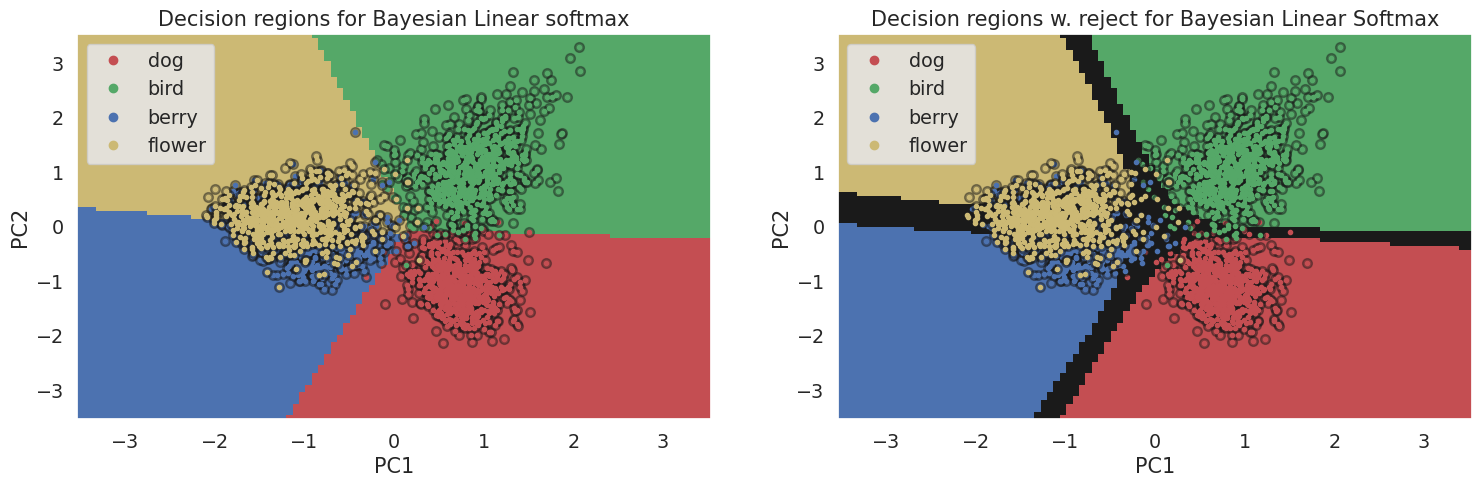

In [87]:
# specify reject threshold
p_reject = 0.6

# compute decisions under 0/1-utility function and reshape to grid
decisions = jnp.argmax(p_pred, axis=1).reshape((len(x_grid), len(x_grid)))

# identify reject regions
p_pred_confidence = confidence(p_pred) # use the function you implemented earlier
reject_region_bls = 1.0*jnp.logical_not((p_pred_confidence < p_reject).reshape((len(x_grid), len(x_grid))))
decisions_with_reject = (decisions+1)*reject_region_bls

# visualize
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))
plot_pca_data(axes[0])
axes[0].pcolormesh(x_grid, x_grid, decisions, cmap=ListedColormap(colors), alpha=1, shading='auto')
axes[0].set_title('Decision regions for Bayesian Linear softmax')
plot_pca_data(axes[1]);
axes[1].pcolormesh(x_grid, x_grid, decisions_with_reject, cmap=ListedColormap(['k'] + colors), shading='auto')
axes[1].set_title('Decision regions w. reject for Bayesian Linear Softmax');



print(jnp.unique(reject_region_bls, return_counts=True))


> **Task 4.1**: Explain what you see in the figure above - relate the **reject region** in black to the confidence plot above [**Discussion question**]

**With reject option**

- The black regions are **reject zones** places where 
$$max_k p(y=k|x) < p_{\text{reject}} = 0.6$$

i.e, the model confidence in its best guess is less than 60%.

- In these regions, the classifier the classifier declines to predict rejects because the probability mass is toospread across classes, indicating uncertainty.  

**Relation to the confidence plot from before**

- In the confidence heatmap you saw earlier, blue areas correspond to low confidence (near 0.3–0.5), and red areas to high confidence (close to 1.0).

- The black bands in the reject-region plot directly overlap those blue low-confidence areas in the confidence plot:

- They hug the decision boundaries where two (or more) classes have similar posterior probability.

- In the multi-class case here, they also form junctions where 3–4 classes meet — these are particularly wide because uncertainty is highest there.

**Interpretation**

- The reject option turns “low-confidence” zones from the confidence plot into “no-decision” zones in the decision-region plot.

- This is essentially Bayesian decision theory with a reject action:

- If $max_k p_k(x)$ is above the threshold, take the class with the largest probability.

- Otherwise, choose “reject” (black).


_______

> **Task 4.2**: What happens to the reject region if you increase or decrease the reject threshold?  [**Discussion question**]


The reject decision is: 
$$
\operatorname{Predict class k } = \arg \max_k p(y=k|x) \quad \text{iff } \max_k p(y=k|x) \ge p_{\text{reject}}
$$
**Intuition**

- Lower threshold → fewer rejections, more aggressive predictions, potential bias toward the class that wins most in uncertain zones.

- Higher threshold → more rejections, safer predictions, only predicting when there’s high confidence.

**Task 4.3**: How many percent of the samples in the test set are rejected with $p_{\text{reject}} = 0.6$?



In [93]:
test_set_reject_idx = confidence(p_test) < p_reject
test_set_keep_idx = confidence(p_test) >= p_reject
print('Fraction of sample rejected: %3.2f' %jnp.mean(test_set_reject_idx))

Fraction of sample rejected: 0.28


**Task 4.4**: What is the test accuracy rate for the samples in the test set, which are not rejected?



In [94]:
y_test_keep = ytest[test_set_keep_idx]
p_test_keep = p_test[test_set_keep_idx]
y_test_keep_hat = jnp.argmax(p_test_keep, axis=1)

print(f'Accuracy on test set (keep): {compute_accuracy(y_test_keep, y_test_keep_hat):.2f}')

Accuracy on test set (keep): 0.89


**Task 4.5**: If we were to make a decision for the test samples in the reject region, what would the accuracy rate be? 



In [95]:
ytest_reject = ytest[test_set_reject_idx]
ptest_reject = p_test[test_set_reject_idx]
ytest_reject_hat = jnp.argmax(ptest_reject, axis=1)

print('Accuracy for rejected samples:\t\t%3.2f' % compute_accuracy(ytest_reject, ytest_reject_hat))

Accuracy for rejected samples:		0.58



**Task 4.6**: Instead, if the reject option, implement the following utility function and plot the corresponding decision boundaries:

- Utility of 1 for correctly classifying dogs, birds, and flowers
- Utility of 2 for correctly classifying berries
- Utility of 0 for all misclassifications



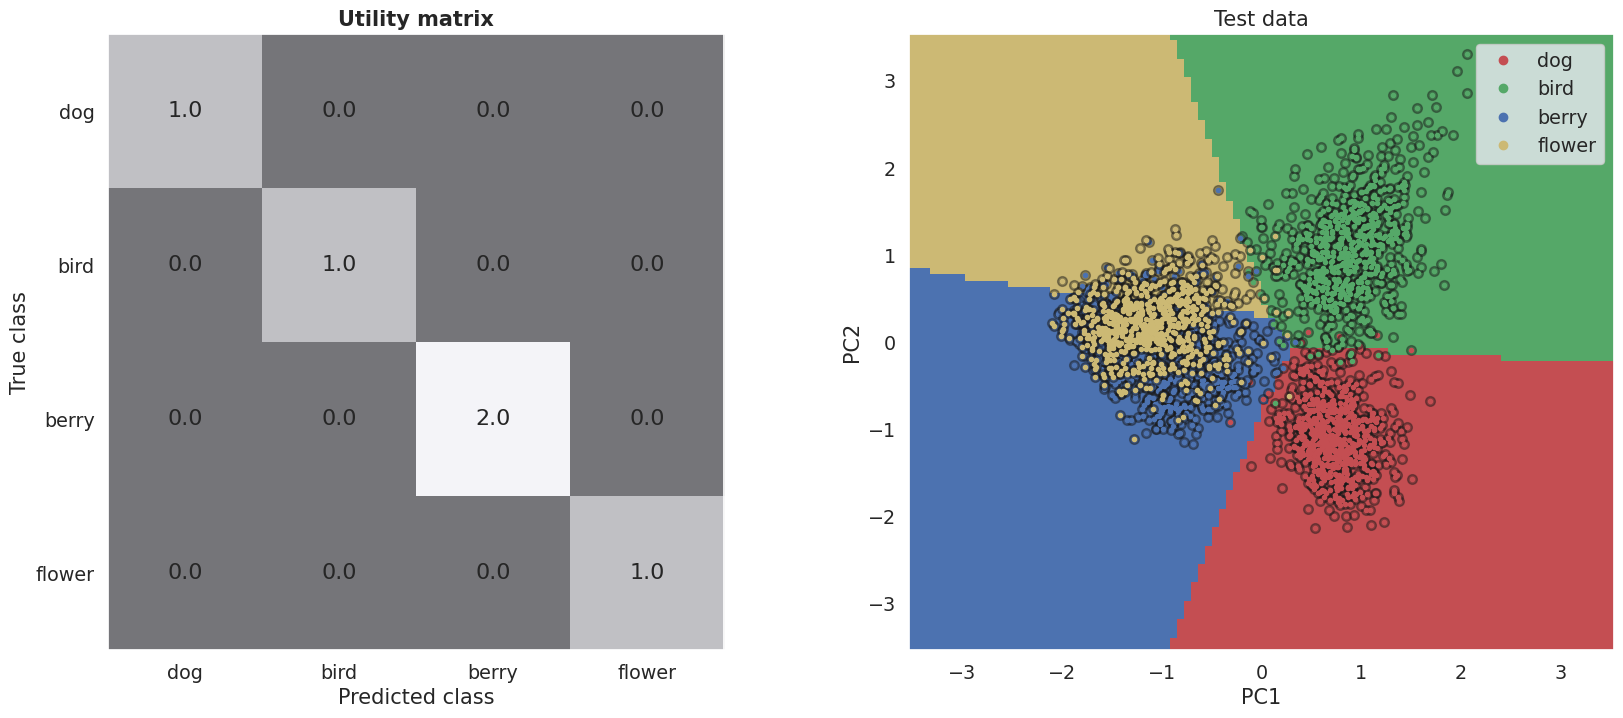

In [98]:
# specify utility  functions
U = jnp.identity(4)
U = U.at[2,2].set(2)

# compute the expected utility for each class for each utility function
expected_utility = compute_expected_utility(U, p_pred)

# make decisions and reshape
decisions = jnp.argmax(expected_utility, axis=1).reshape((len(x_grid), len(x_grid)))

# plot
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
visualize_utility(axes[0], U, labels=labels)
axes[1].pcolormesh(x_grid, x_grid, decisions, cmap=ListedColormap(colors), alpha=1, shading='auto')
axes[1].set_title('Decision regions for $U_{%d}$' % (i+1))
plot_pca_data(axes[1]);


# 🍓 Boosting Berry’s Utility: U_{2,2} = 2

## Setup
Let $p_k(x) = p(y=k \mid x)$ and $E[U_k] = \sum_j p_j(x)\,U_{j,k}.$

We start from 0/1 utility (identity) and change only the **berry** diagonal:
$U_{2,2} = 2.$

All other diagonals remain 1; all off-diagonals are 0.

---

## Expected utilities
- Dog: $E[U_{\text{dog}}] = p_{\text{dog}}(x)$
- Bird: $E[U_{\text{bird}}] = p_{\text{bird}}(x)$
- **Berry**: $E[U_{\text{berry}}] = 2\,p_{\text{berry}}(x)$
- Flower: $E[U_{\text{flower}}] = p_{\text{flower}}(x)$

Decision rule: $\hat{y}(x)=\arg\max_k E[U_k].$

---

## Boundary: berry vs. flower
Solve for equality of expected utilities:
$
2\,p_{\text{berry}}(x) \;=\; p_{\text{flower}}(x)
\;\;\Longleftrightarrow\;\;
p_{\text{berry}}(x) \;=\; 0.5\,p_{\text{flower}}(x).
$

**Interpretation**
- Predict **berry** even when $p_{\text{berry}}(x) < p_{\text{flower}}(x)$, as long as $p_{\text{berry}}(x) \ge 0.5\,p_{\text{flower}}(x)$.  
- Berry’s region **expands**; flower’s region **shrinks**.
- The same tilt applies versus dog and bird: boundaries move **away from berry**.

---

## General rule (handy)
If you scale class $k$’s correct-utility by $\alpha_k>0$ (i.e., $U_{k,k}=\alpha_k$), then the $k$ vs. $\ell$ boundary satisfies:
$$
\alpha_k\,p_k(x) \;=\; \alpha_\ell\,p_\ell(x)
\;\;\Longleftrightarrow\;\;
\frac{p_k(x)}{p_\ell(x)} \;=\; \frac{\alpha_\ell}{\alpha_k}.
$$
Larger $\alpha_k$ → **bigger** region for class $k$.
# 🍓 Two-Class Walkthrough: Berry vs. Flower with Utility Scaling

## Step 1 — Posteriors at a point
Inline probabilities:
- $p_{\text{berry}}(x)=0.4$
- $p_{\text{flower}}(x)=0.6$

---

## Step 2 — Equal utilities ($\alpha_k=\alpha_\ell=1$)

- Expected utility (berry): $1 \cdot 0.4 = 0.4$  
- Expected utility (flower): $1 \cdot 0.6 = 0.6$  
**Winner:** flower.

**Boundary condition (tie):**
$$
\frac{p_{\text{berry}}(x)}{p_{\text{flower}}(x)} \;=\; \frac{\alpha_{\text{flower}}}{\alpha_{\text{berry}}} \;=\; \frac{1}{1} \;=\; 1
\quad\Rightarrow\quad
p_{\text{berry}}(x)=p_{\text{flower}}(x).
$$

---

## Step 3 — Boost berry’s utility ($\alpha_{\text{berry}}=2, \alpha_{\text{flower}}=1$)

- Expected utility (berry): $$2 \cdot 0.4 = 0.8$$  
- Expected utility (flower): $$1 \cdot 0.6 = 0.6$$  
**Winner:** berry.

**Boundary condition now:**
$$
\frac{p_{\text{berry}}(x)}{p_{\text{flower}}(x)} \;=\; \frac{\alpha_{\text{flower}}}{\alpha_{\text{berry}}} \;=\; \frac{1}{2} \;=\; 0.5.
$$

**Meaning:** Berry can win even when its probability is only **half** of flower’s probability.

---

## Step 4 — Visual intuition
- Increasing $$\alpha_{\text{berry}}$$ expands berry’s decision region into flower’s region.
- The larger $$\alpha_{\text{berry}}$$ is, the **less** posterior probability berry needs to beat flower.

---

## Summary table

| $$\alpha_{\text{berry}}$$ | $$\alpha_{\text{flower}}$$ | Boundary condition $$p_b/p_f$$ | Effect |
|---:|---:|:---:|:---|
| 1 | 1 | 1.0 | Tie when probabilities are equal (standard MAP). |
| 2 | 1 | 0.5 | Berry wins even if less probable. |
| 0.5 | 1 | 2.0 | Berry must be much more probable to win. |

---

## General rule (useful to remember)
For any two classes $k$ and $\ell$ with diagonal utilities $U_{k,k}=\alpha_k$ and $U_{\ell,\ell}=\alpha_\ell$, the $k$ vs. $\ell$ boundary satisfies
$$
\alpha_k\,p_k(x) \;=\; \alpha_\ell\,p_\ell(x)
\quad\Longleftrightarrow\quad
\frac{p_k(x)}{p_\ell(x)} \;=\; \frac{\alpha_\ell}{\alpha_k}.
$$
Larger $\alpha_k$ ⇒ larger decision region for class $k$.


---

## Minimal code (NumPy/JAX)
```python
# U = identity, then boost berry (index 2)
U = jnp.eye(4)
U = U.at[2, 2].set(2.0)

# phat is shape [P, 4] of posterior predictive probs
expected_utility = phat @ U                    # shape [P, 4]
yhat = jnp.argmax(expected_utility, axis=1)    # decisions


## Part 5:  Model calibration

As we have seen, the posterior predictive probabilities play a key role in decision-making. In the last part of this exercise, we will study calibration of these probabilities using the **expected calibration error (ECE)**-metric and so-called **reliability plots** (see Section 14.2.2.1 or pages 578 in Murphy2).

In this exercise, we will use the test set $\left\lbrace \mathbf{x}_m^*, y^*_m \right\rbrace_{m=1}^M$ to evaluate these metrics. Let $$\hat{y}^*_m = \arg\max_k p(y^*_m = k|\mathbf{y}, \mathbf{x}^*m)$$ be the decision (under the 0/1-utility function) for the $m$'th test point and let $$\mathcal{C}_m = \max_k p(y^*_m = k|\mathbf{y}, \mathbf{x}^*_m)$$ be the corresponding confidence. We will divide the unit interval in $B$ bins and estimate the average accuracy and confidence for each bin:

$$\begin{align*}
\text{acc}(\mathcal{B}_b) &= \frac{1}{|\mathcal{B}_b|} \sum_{m \in \mathcal{B}_b} \mathbb{I}\left(\hat{y}^*_m = y^*_m\right)\\
\text{conf}(\mathcal{B}_b) &= \frac{1}{|\mathcal{B}_b|} \sum_{m \in \mathcal{B}_b} \mathcal{C}_m,
\end{align*}$$

where $\mathcal{B}_b$ contains all the indices of points falling into the $b$'th bin. Then the ECE is defined as

$$\begin{align*}
\text{ECE} = \sum_{b=1}^B \frac{|\mathcal{B}_b|}{M}|\text{acc}(\mathcal{B}_b) - \text{conf}(\mathcal{B}_b)|.
\end{align*}$$

**Note**: The ECE is **not** a so-called *proper scoring rule*, and therefore, we rely solely ECE for model evaluation. In fact, a model can be useless without any predictive power, but still be perfectly calibrated. Therefore, we should always also look at metrics like accuracy, ELPD, log likelihood etc. to make sure the model performs as intended. However, the ECE can be really useful to assess the calibration-aspect specifically.

It is often also useful to plot $\text{acc}(\mathcal{B}_b)$ as a function of $\text{conf}(\mathcal{B}_b)$ for each bin. This is called **reliability plot** or **calibration plot** and may provide insights into whether the model are generally over or underconfident. 

**Interpretation**

- ECE=0 ⇒ **perfect calibration**: in every bin, empirical accuracy matches stated confidence.  
- Positive ECE just measures **magnitude** of miscalibration (not direction).  
  - If $\text{conf}(B_b)>\text{acc}(B_b)$ ⇒ **overconfident** in that range.  
  - If $\text{conf}(B_b)<\text{acc}(B_b)$ ⇒ **underconfident** in that range.

## Tiny example
Take $M=100$, $B=10$, and bin $I_9=(0.8,0.9]$ with $|B_9|=20$, $\text{conf}(B_9)=0.85$, and $\text{acc}(B_9)=0.75$.  
Its contribution is
$$
\frac{|B_9|}{M}\,|\text{acc}-\text{conf}|
=\frac{20}{100}\,|0.75-0.85|=0.02.
$$

## Reliability plot
Plot $\text{acc}(B_b)$ (y-axis) vs. $\text{conf}(B_b)$ (x-axis):
- Ideal line: $y=x$.  
- Points **below** the diagonal ⇒ overconfidence; **above** ⇒ underconfidence.  
A companion histogram of $|B_b|$ shows where data mass lies (miscalibration in sparse regions matters less).

## Note & best practice
- **ECE is not a proper scoring rule**; do not use it alone. A model can be perfectly calibrated yet uninformative.  
- Always pair with performance metrics (accuracy, NLL/log-loss, ELPD).  
- Variants (e.g., classwise ECE, adaptive binning) can mitigate class/coverage biases, but the core idea is unchanged.



**Task 5.1**: Set $\alpha = 1$. Compute the posterior predictive distribution for the test set of the image classification problem. Compute and plot a histogram of the confidences for each predictions. Repeat for $\alpha=10^{-2}$ and $\alpha=10^2$. How does $\alpha$ generally affect the confidences? Can you explain why?



**Task 5.2**: Implement a function for estimating the expected calibration error (ECE) metric as well as for making a reliability plot. Compute the ECE and the plot reliability for the following values of $\alpha \in \left\lbrace 10^{-2}, 1, 10^2 \right\rbrace$. Compare the reliability plots to the histograms in the previous exercise.




f_all_samples (4, 2880, 1000)
f_all_samples (4, 2880, 1000)
f_all_samples (4, 2880, 1000)


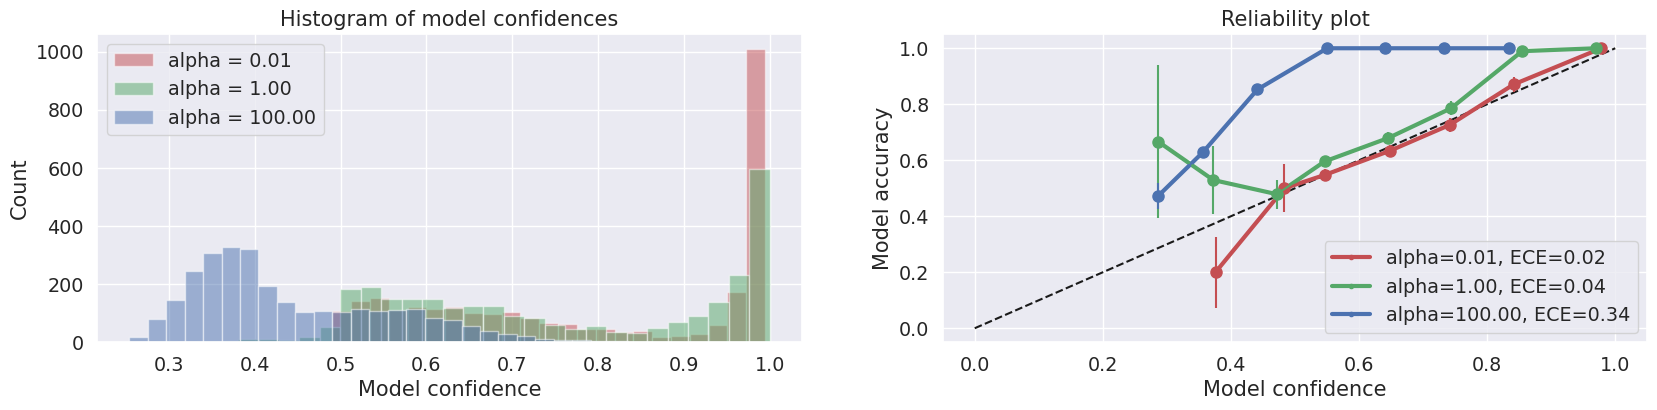

In [99]:
def compute_calibration_curve(ytrue, yhat, probs, num_bins=10):

    # create bins
    bins = jnp.linspace(0, 1, num_bins+1)

    # compute identify correct predictions and compute confidence
    correct_all = 1.0*(ytrue == yhat)
    conf_all = confidence(probs)

    # preallocate lists
    acc_bin, acc_bin_se, conf_bin, point_in_bins = [], [], [], []

    # loop through each bin
    for i in range(num_bins):
        bin_start, bin_end = bins[i], bins[i+1]        
        bin_idx = jnp.logical_and(bin_start <= conf_all, conf_all < bin_end)
        num_points_in_bin = jnp.sum(bin_idx)

        # don't want to bother with empty bins
        if len(correct_all[bin_idx]) == 0:
            continue
        
        # store results
        conf_bin.append(jnp.mean(conf_all[bin_idx]))
        acc = jnp.mean(correct_all[bin_idx])
        acc_bin.append(acc)
        acc_bin_se.append(jnp.sqrt(acc*(1-acc)/num_points_in_bin))
        point_in_bins.append(len(correct_all[bin_idx]))

    acc_bin = jnp.array(acc_bin)
    acc_bin_se = jnp.array(acc_bin_se)
    conf_bin = jnp.array(conf_bin)
    point_in_bins = jnp.array(point_in_bins)

    # compute ECE
    ECE = jnp.sum(point_in_bins*jnp.abs(acc_bin-conf_bin))/len(ytrue)

        
    return ECE, acc_bin, acc_bin_se, conf_bin, point_in_bins

# specify list of alphas
alphas = [1e-2, 1., 1e2]

# prep plot
fig, ax = plt.subplots(1, 2, figsize=(20, 4))
ax[1].plot([0, 1], [0, 1], 'k--')

def design_matrix(X):
    return jnp.column_stack((jnp.ones(len(X)), X))

for i, alpha in enumerate(alphas):

    # fit model and compute posterior predictive probabilities and predictions (under the 0/1 utility function)
    model = BayesianLinearSoftmax(X_train, ytrain, alpha=alpha)
    ptest = model.predict_y(X_test, 1000)
    ytest_hat = jnp.argmax(ptest, 1)

    ECE, acc, acc_se, conf, num = compute_calibration_curve(ytest, ytest_hat, ptest)
    ax[0].hist(confidence(ptest), 30, alpha=0.5, label=f'alpha = {alpha:3.2f}', color=colors[i])
    ax[1].plot(conf, acc, '.-', label=f'alpha={alpha:3.2f}, ECE={ECE:3.2f}', linewidth=3, color=colors[i])
    ax[1].errorbar(conf, acc, acc_se, color=colors[i], marker='o', markersize=8)


ax[0].set(xlabel='Model confidence', ylabel='Count', title='Histogram of model confidences')
ax[1].set(xlabel='Model confidence', ylabel='Model accuracy', title='Reliability plot')
ax[0].legend()
ax[1].legend()

## 📊 What You Should See (and Why)

- **$\alpha = 1$**: Baseline spread of confidences.

- **$\alpha = 10^{2}$**: Histogram mass piles up near **1**.  
  *Intuition*: For the top two classes $p_{(1)} \ge p_{(2)}$, the ratio after tempering is  
  $$
  \left( \frac{p_{(1)}}{p_{(2)}} \right)^\alpha.
  $$  
  With large $\alpha$, this ratio explodes, so the top class grabs almost all probability mass ⇒ **confidences $\approx 1$**.

- **$\alpha = 10^{-2}$**: Histogram collapses near $1/K$.  
  As $\alpha \to 0^+$, $p_k^\alpha \to 1$ for all $k$ with $p_k > 0$, so the normalized vector tends to uniform ⇒ **confidences $\approx 1/K$**.

---

## 💡 Practical Tip

- Extreme $\alpha$ can cause numerical issues; use the **log / log-sum-exp** formulation to keep things stable for both $\alpha = 10^{-2}$ and $\alpha = 10^{2}$.
- Changing $\alpha$ won’t change accuracy (same $\arg\max$), but it will change **calibration metrics** like **ECE**:  
  - Large $\alpha$ often **increases overconfidence**.  
  - Small $\alpha$ often **reduces overconfidence**.
- To learn a good temperature, fit $T = 1/\alpha$ on a **validation set** by minimizing **NLL** (a proper scoring rule).
